# Spatiotemporal and Meteorological Analysis of Odor Complaints (Pittsburgh)

This notebook replicates the methodology and analyses of the Seoul megacity odor study, adapted for daily and monthly complaints in Pittsburgh.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 2. Load and Prepare Your Dataset


In [2]:
# Load the merged dataset we generated
import os
file_path = 'open-meteo-smell-merged.csv'
if not os.path.exists(file_path) and os.path.exists(os.path.join('Pittsburgh Data', file_path)):
    file_path = os.path.join('Pittsburgh Data', file_path)

print(f"Reading dataset from: {file_path}")
df_raw = pd.read_csv(file_path)

# Map our columns to the names expected by the notebook
column_mapping = {
    'time': 'datetime',
    'smell_report_count': 'complaints',
    'temperature_2m (°F)': 'temperature',
    'relative_humidity_2m (%)': 'relative_humidity',
    'wind_speed_10m (mp/h)': 'wind_speed',
    'wind_direction_10m (°)': 'wind_direction',
    'rain (inch)': 'precipitation',
    'dew_point_2m (°F)': 'dew_point',
    'vapour_pressure_deficit (kPa)': 'vapor_pressure',
    'surface_pressure (hPa)': 'atmospheric_pressure',
    'shortwave_radiation (W/m²)': 'solar_radiation',
    'sunshine_duration (s)': 'sunshine_duration',
    'boundary_layer_height (ft)': 'boundary_layer_height'
}
df_mapped = df_raw.rename(columns=column_mapping)
df_mapped['datetime'] = pd.to_datetime(df_mapped['datetime'])

# Keep the zipcode-level hourly data in a separate variable
df_zipcode = df_mapped.copy()

# Aggregate the zipcode-level data to a city-wide hourly dataset for baseline analysis
df = df_mapped.groupby('datetime').agg({
    'complaints': 'sum',
    'temperature': 'mean',
    'precipitation': 'mean',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'dew_point': 'mean',
    'relative_humidity': 'mean',
    'vapor_pressure': 'mean',
    'atmospheric_pressure': 'mean',
    'sunshine_duration': 'mean',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean',
    'smell_value_average': 'mean'
}).reset_index()

# Ensure required temporal columns exist for hourly distributions
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['dayofweek'].isin([5, 6])

print("Hourly city-wide data loaded successfully! Shape:", df.shape)

# Aggregate hourly data to daily data for meteorological analysis
# As per the paper's methodology, correlation and regression analyses use daily metrics.
daily_df = df.groupby('date').agg({
    'complaints': 'sum',
    'is_weekend': 'first',
    'temperature': ['mean', 'min', 'max'],
    'precipitation': 'sum',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'dew_point': 'mean',
    'relative_humidity': 'mean',
    'vapor_pressure': 'mean',
    'atmospheric_pressure': 'mean',
    'sunshine_duration': 'sum',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean',
    'smell_value_average': 'mean'
}).reset_index()

# Flatten multi-index columns
daily_df.columns = [
    'date', 'complaints', 'is_weekend',
    'temperature', 'temp_min', 'temp_max',
    'precipitation', 'wind_speed', 'wind_direction',
    'dew_point', 'relative_humidity', 'vapor_pressure',
    'atmospheric_pressure', 'sunshine_duration',
    'solar_radiation', 'boundary_layer_height', 'smell_value_average'
]

# Calculate Diurnal Temperature Range (DTR)
daily_df['diurnal_temperature_range'] = daily_df['temp_max'] - daily_df['temp_min']

# Create a temperature bin column for grouping
# Load smell reports to filter for severity >= 3
smell_file_path = 'smell_reports_pittsburgh.csv'
if not os.path.exists(smell_file_path) and os.path.exists(os.path.join(os.path.dirname('Pittsburgh Data/Odor_Complaint_Analysis_v2.ipynb'), smell_file_path)):
    smell_file_path = os.path.join(os.path.dirname('Pittsburgh Data/Odor_Complaint_Analysis_v2.ipynb'), smell_file_path)

print(f"Reading raw smell reports from: {smell_file_path}")
smell_df = pd.read_csv(smell_file_path)
smell_df['datetime_aware'] = pd.to_datetime(smell_df['date & time'], utc=True)
smell_df['datetime_local'] = smell_df['datetime_aware'].dt.tz_convert('America/New_York')
smell_df['date'] = smell_df['datetime_local'].dt.date

# Filter for smell value >= 3 (of concern)
smell_high = smell_df[smell_df['smell value'] >= 3]
daily_high = smell_high.groupby('date').size().rename('high_complaints')

# Merge daily_high into daily_df
daily_df = daily_df.merge(daily_high, on='date', how='left').fillna({'high_complaints': 0})

print("Daily city-wide aggregation complete! Shape:", daily_df.shape)

# Create a date datetime column
daily_df['date_dt'] = pd.to_datetime(daily_df['date'])

# For Pittsburgh, all years are fully populated (2018-2026), so no sparse years to exclude.
daily_corr = daily_df.copy()
print(f"Correlation analysis subset (all years 2018+): {len(daily_corr)} days")

# Monthly aggregation for Seoul-style analysis
daily_corr['month'] = daily_corr['date_dt'].dt.to_period('M')

monthly_df = daily_corr.groupby('month').agg({
    'complaints': 'mean',   # average daily complaints per month
    'temperature': 'mean',
    'precipitation': 'mean',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'dew_point': 'mean',
    'relative_humidity': 'mean',
    'vapor_pressure': 'mean',
    'atmospheric_pressure': 'mean',
    'sunshine_duration': 'mean',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

# Also create weekday/weekend monthly aggregations
monthly_wd = daily_corr[~daily_corr['is_weekend']].groupby('month').agg({
    'complaints': 'mean',
    'temperature': 'mean', 'precipitation': 'mean',
    'wind_speed': 'mean', 'wind_direction': 'mean',
    'dew_point': 'mean', 'relative_humidity': 'mean',
    'vapor_pressure': 'mean', 'atmospheric_pressure': 'mean',
    'sunshine_duration': 'mean', 'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

monthly_we = daily_corr[daily_corr['is_weekend']].groupby('month').agg({
    'complaints': 'mean',
    'temperature': 'mean', 'precipitation': 'mean',
    'wind_speed': 'mean', 'wind_direction': 'mean',
    'dew_point': 'mean', 'relative_humidity': 'mean',
    'vapor_pressure': 'mean', 'atmospheric_pressure': 'mean',
    'sunshine_duration': 'mean', 'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

print(f"Monthly aggregation complete: {len(monthly_df)} months ({len(monthly_wd)} weekday, {len(monthly_we)} weekend)")


Reading dataset from: open-meteo-smell-merged.csv
Hourly city-wide data loaded successfully! Shape: (73888, 19)
Reading raw smell reports from: smell_reports_pittsburgh.csv
Daily city-wide aggregation complete! Shape: (3080, 19)
Correlation analysis subset (all years 2018+): 3080 days
Monthly aggregation complete: 103 months (102 weekday, 103 weekend)


## 3. Spatiotemporal Characteristics


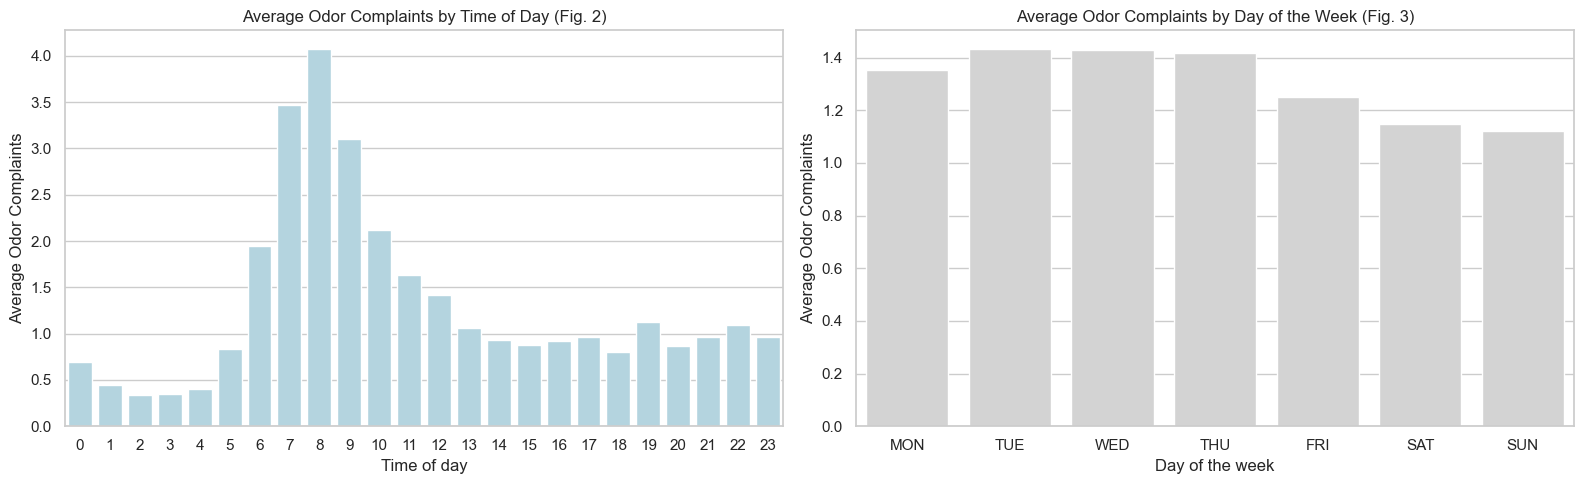

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly Distribution (Fig. 2)
sns.barplot(x='hour', y='complaints', data=df, color='lightblue', errorbar=None, ax=axes[0])
axes[0].set_title('Average Odor Complaints by Time of Day (Fig. 2)')
axes[0].set_xlabel('Time of day')
axes[0].set_ylabel('Average Odor Complaints')

# Weekly Distribution (Fig. 3)
sns.barplot(x='dayofweek', y='complaints', data=df, color='lightgray', errorbar=None, ax=axes[1])
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'])
axes[1].set_title('Average Odor Complaints by Day of the Week (Fig. 3)')
axes[1].set_xlabel('Day of the week')
axes[1].set_ylabel('Average Odor Complaints')

plt.tight_layout()
plt.show()


## 4. Meteorological Influences


In [4]:
# Separate data by weekdays and weekends to assess lifestyle behavior shifts
# Using 2018+ filtered data
df_weekday = daily_corr[~daily_corr['is_weekend']]
df_weekend = daily_corr[daily_corr['is_weekend']]

meteo_vars = ['temperature', 'precipitation', 'wind_speed', 'wind_direction',
              'dew_point', 'relative_humidity', 'vapor_pressure',
              'atmospheric_pressure', 'sunshine_duration', 'solar_radiation',
              'boundary_layer_height']

results = []
for var in meteo_vars:
    wd_clean = df_weekday[['complaints', var]].dropna()
    we_clean = df_weekend[['complaints', var]].dropna()

    if len(wd_clean) >= 3 and wd_clean[var].std() > 0:
        r_wd, p_wd = pearsonr(wd_clean['complaints'], wd_clean[var])
    else:
        r_wd, p_wd = np.nan, np.nan
    if len(we_clean) >= 3 and we_clean[var].std() > 0:
        r_we, p_we = pearsonr(we_clean['complaints'], we_clean[var])
    else:
        r_we, p_we = np.nan, np.nan

    results.append({
        'Meteorological Variable': var.replace('_', ' ').title(),
        'Weekday r': r_wd, 'Weekday p-value': p_wd,
        'Weekend r': r_we, 'Weekend p-value': p_we
    })

corr_table = pd.DataFrame(results).round(3)
print("\n=== DAILY Pearson Correlations (2018+, Weekday/Weekend) ===")
print(corr_table)



=== DAILY Pearson Correlations (2018+, Weekday/Weekend) ===
   Meteorological Variable  Weekday r  Weekday p-value  Weekend r  \
0              Temperature      0.097            0.000      0.114   
1            Precipitation     -0.123            0.000     -0.087   
2               Wind Speed     -0.239            0.000     -0.276   
3           Wind Direction     -0.235            0.000     -0.196   
4                Dew Point      0.045            0.036      0.086   
5        Relative Humidity     -0.146            0.000     -0.061   
6           Vapor Pressure      0.192            0.000      0.159   
7     Atmospheric Pressure      0.124            0.000      0.142   
8        Sunshine Duration      0.149            0.000      0.145   
9          Solar Radiation      0.094            0.000      0.090   
10   Boundary Layer Height     -0.336            0.000     -0.320   

    Weekend p-value  
0             0.001  
1             0.010  
2             0.000  
3             0.000  


### Monthly Pearson Correlation Table (Seoul-Style)


In [5]:
# Monthly Pearson Correlation Table (Seoul Table 2 equivalent)
# The Seoul study achieved much higher r values because monthly averaging
# smooths day-to-day noise in complaint counts.
from scipy.stats import spearmanr

monthly_results = []
for var in meteo_vars:
    wd_clean = monthly_wd[['complaints', var]].dropna()
    we_clean = monthly_we[['complaints', var]].dropna()

    if len(wd_clean) >= 3 and wd_clean[var].std() > 0:
        r_wd, p_wd = pearsonr(wd_clean['complaints'], wd_clean[var])
    else:
        r_wd, p_wd = np.nan, np.nan
    if len(we_clean) >= 3 and we_clean[var].std() > 0:
        r_we, p_we = pearsonr(we_clean['complaints'], we_clean[var])
    else:
        r_we, p_we = np.nan, np.nan

    monthly_results.append({
        'Meteorological Variable': var.replace('_', ' ').title(),
        'Weekday r': r_wd, 'Weekday p-value': p_wd,
        'Weekend r': r_we, 'Weekend p-value': p_we
    })

monthly_corr_table = pd.DataFrame(monthly_results).round(3)
print("\n=== MONTHLY Pearson Correlations (Seoul-Style, 2018+) ===")
print(monthly_corr_table)

# Spearman rank correlations on daily data (more robust for zero-inflated counts)
spearman_results = []
df_weekday_corr = daily_corr[~daily_corr['is_weekend']]
df_weekend_corr = daily_corr[daily_corr['is_weekend']]

for var in meteo_vars:
    wd_clean = df_weekday_corr[['complaints', var]].dropna()
    we_clean = df_weekend_corr[['complaints', var]].dropna()

    if len(wd_clean) >= 3:
        rho_wd, p_wd = spearmanr(wd_clean['complaints'], wd_clean[var])
    else:
        rho_wd, p_wd = np.nan, np.nan
    if len(we_clean) >= 3:
        rho_we, p_we = spearmanr(we_clean['complaints'], we_clean[var])
    else:
        rho_we, p_we = np.nan, np.nan

    spearman_results.append({
        'Meteorological Variable': var.replace('_', ' ').title(),
        'Weekday rho': rho_wd, 'Weekday p-value': p_wd,
        'Weekend rho': rho_we, 'Weekend p-value': p_we
    })

spearman_table = pd.DataFrame(spearman_results).round(3)
print("\n=== DAILY Spearman Rank Correlations (2018+, robust to zero-inflation) ===")
print(spearman_table)



=== MONTHLY Pearson Correlations (Seoul-Style, 2018+) ===
   Meteorological Variable  Weekday r  Weekday p-value  Weekend r  \
0              Temperature     -0.020            0.846      0.110   
1            Precipitation     -0.147            0.141     -0.108   
2               Wind Speed      0.019            0.851     -0.179   
3           Wind Direction     -0.168            0.091     -0.273   
4                Dew Point     -0.073            0.465      0.083   
5        Relative Humidity     -0.357            0.000     -0.134   
6           Vapor Pressure      0.064            0.526      0.110   
7     Atmospheric Pressure      0.176            0.076      0.147   
8        Sunshine Duration      0.040            0.689      0.150   
9          Solar Radiation     -0.020            0.843      0.059   
10   Boundary Layer Height     -0.076            0.445     -0.204   

    Weekend p-value  
0             0.271  
1             0.280  
2             0.070  
3             0.005  
4 

### 4.2 Linear Regression of Key Variables (Refers to Figure 6 in the paper)


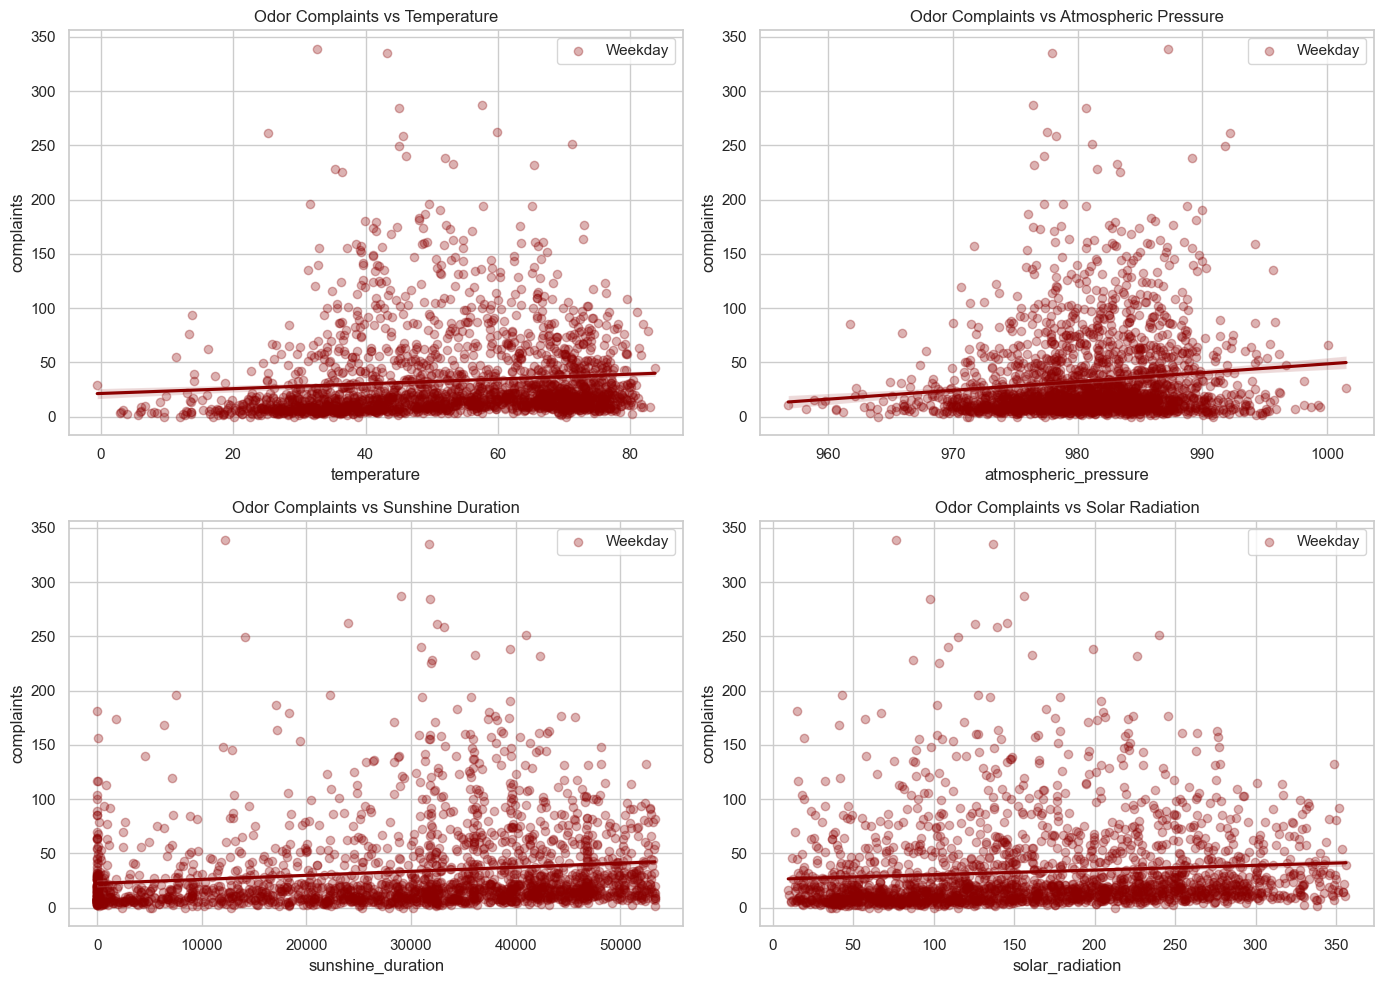

In [6]:
# Evaluate the associations between daily odor complaint frequencies and the top four meteorological drivers
key_vars = ['temperature', 'atmospheric_pressure', 'sunshine_duration', 'solar_radiation']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes[i]
    sns.regplot(x=var, y='complaints', data=df_weekday, ax=ax, label='Weekday', color='darkred', scatter_kws={'alpha':0.3})
    ax.set_title(f'Odor Complaints vs {var.replace("_", " ").title()}')
    ax.legend()

plt.tight_layout()
plt.show()


### Monthly Scatter Regression Plots (All Variables)


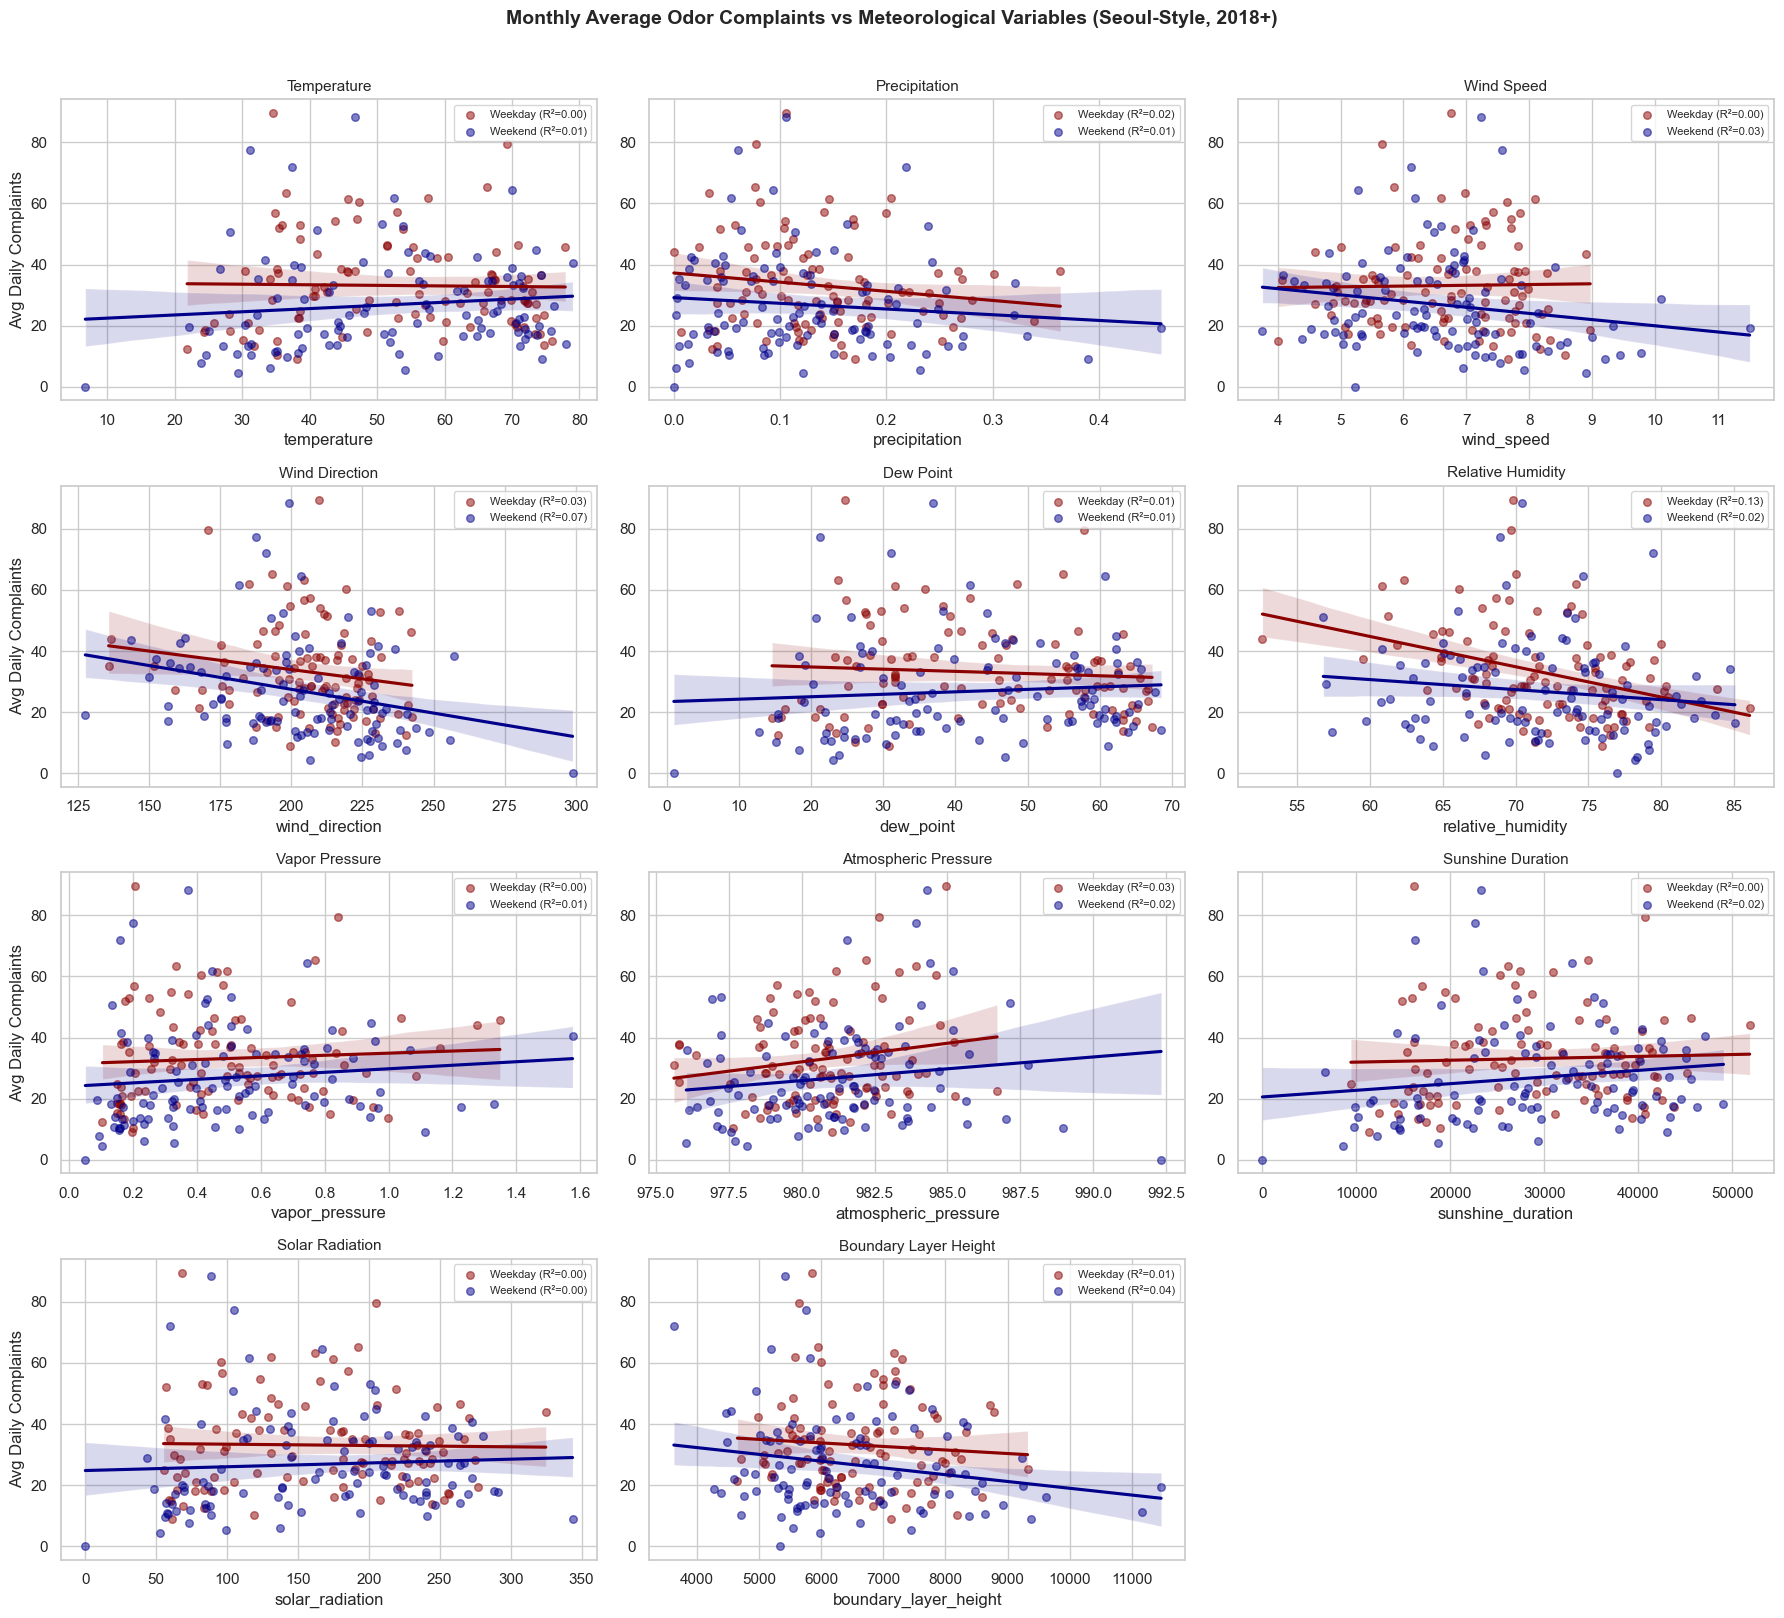

In [7]:
# Monthly Scatter Regression Plots for ALL meteorological variables
# This replicates the Seoul study's Fig. 6 approach, using monthly averages
# to reveal the weather-odor relationships that are obscured at the daily level.
all_meteo_vars = ['temperature', 'precipitation', 'wind_speed', 'wind_direction',
                  'dew_point', 'relative_humidity', 'vapor_pressure',
                  'atmospheric_pressure', 'sunshine_duration', 'solar_radiation',
                  'boundary_layer_height']

# Compute R² values for titles
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

n_vars = len(all_meteo_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(all_meteo_vars):
    ax = axes[i]

    # Drop NaN rows for this variable
    wd_clean = monthly_wd[['complaints', var]].dropna()
    we_clean = monthly_we[['complaints', var]].dropna()

    if len(wd_clean) < 3 or len(we_clean) < 3:
        ax.set_title(f'{var.replace("_", " ").title()} (insufficient data)', fontsize=11)
        ax.text(0.5, 0.5, 'Not enough data', transform=ax.transAxes, ha='center', va='center')
        continue

    # Weekday monthly data
    x_wd = wd_clean[var].values.reshape(-1, 1)
    y_wd = wd_clean['complaints'].values
    lr_wd = LinearRegression().fit(x_wd, y_wd)
    r2_wd = r2_score(y_wd, lr_wd.predict(x_wd))

    # Weekend monthly data
    x_we = we_clean[var].values.reshape(-1, 1)
    y_we = we_clean['complaints'].values
    lr_we = LinearRegression().fit(x_we, y_we)
    r2_we = r2_score(y_we, lr_we.predict(x_we))

    sns.regplot(x=var, y='complaints', data=wd_clean, ax=ax,
                label=f'Weekday (R²={r2_wd:.2f})', color='darkred', scatter_kws={'alpha': 0.5, 's': 30})
    sns.regplot(x=var, y='complaints', data=we_clean, ax=ax,
                label=f'Weekend (R²={r2_we:.2f})', color='darkblue', scatter_kws={'alpha': 0.5, 's': 30})

    ax.set_title(f'{var.replace("_", " ").title()}', fontsize=11)
    ax.set_ylabel('Avg Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=8, loc='best')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Monthly Average Odor Complaints vs Meteorological Variables (Seoul-Style, 2018+)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.4 Binned Daily Meteorological Analysis (Normalized Rate)

**Methodology:**
To eliminate the baseline frequency bias (where certain weather conditions appear to have more complaints simply because they occur more frequently), we group the raw daily meteorological data into weather bins. For each bin, we calculate the true average daily complaint rate as:

$$\text{Average Daily Complaints} = \frac{\text{Total complaints on days matching the bin}}{\text{Total number of days falling in that bin}}$$

By standardizing the total complaints by the count of days in each bin, we obtain a frequency-adjusted rate. This analysis uses all daily complaints (matching the target variable of the multivariate count model) to ensure consistency.

**Precipitation Outlier Note:** In the binned daily precipitation plots, you may notice an apparent outlier where the complaint rate remains high despite measurable daily precipitation. An hourly investigation of these specific dates (e.g. Feb 24, 2020 and Mar 25, 2021 in Pittsburgh) shows this is a **temporal aggregation artifact**. On all such days, the odor complaints peaked sharply in the dry morning hours (6:00 AM – 11:00 AM), whereas the precipitation fell much later in the afternoon or late evening. This confirms the physical hypothesis that active rain suppresses odors, but daily aggregation masks this timing, creating a false visual outlier.

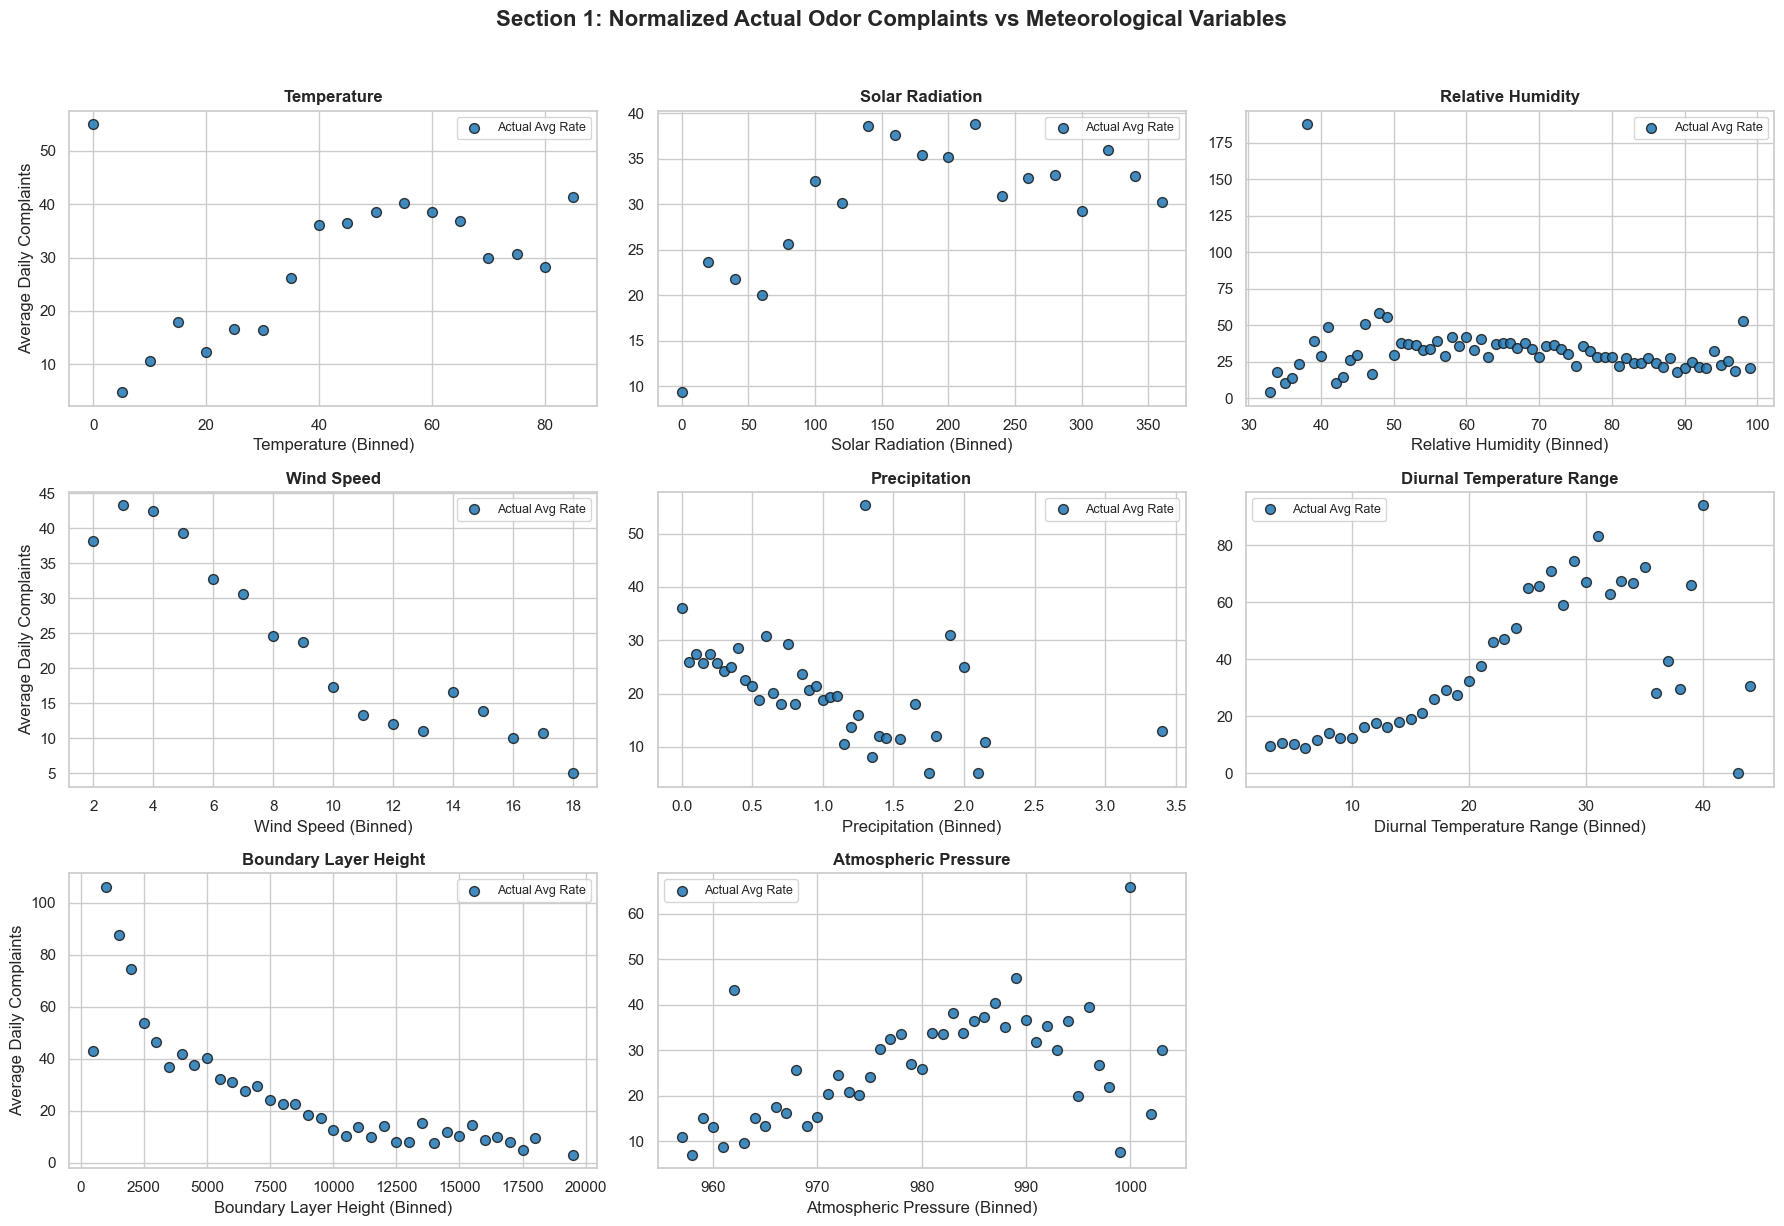

In [8]:
# Define target weather variables in the model
target_weather_vars = [
    'temperature',
    'solar_radiation',
    'relative_humidity',
    'wind_speed',
    'precipitation',
    'diurnal_temperature_range',
    'boundary_layer_height',
    'atmospheric_pressure'
]

def bin_variable(series, name):
    if name == 'temperature':
        return (series / 5).round() * 5
    elif name == 'precipitation':
        return (series / 0.05).round() * 0.05
    elif name == 'wind_speed':
        return series.round()
    elif name == 'relative_humidity':
        return series.round()
    elif name == 'atmospheric_pressure':
        return series.round()
    elif name == 'solar_radiation':
        return (series / 20).round() * 20
    elif name == 'boundary_layer_height':
        return (series / 500).round() * 500
    elif name == 'diurnal_temperature_range':
        return series.round()
    return series

# Pre-calculate binned columns
for var in target_weather_vars:
    daily_df[f'{var}_binned'] = bin_variable(daily_df[var], var)

n_vars = len(target_weather_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(target_weather_vars):
    ax = axes[i]
    binned_col = f'{var}_binned'

    # Calculate binned daily average rate (Total complaints in bin / Total days in bin)
    binned_data = daily_df.groupby(binned_col).agg(
        avg_complaints=('complaints', 'mean'),
        num_days=('complaints', 'count')
    ).reset_index()

    binned_data = binned_data[binned_data['num_days'] >= 1]

    ax.scatter(binned_data[binned_col], binned_data['avg_complaints'],
               color='#1f77b4', alpha=0.85, edgecolor='k', s=50, label='Actual Avg Rate')

    ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' ').title() + ' (Binned)')
    ax.set_ylabel('Average Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=9, loc='best')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Section 1: Normalized Actual Odor Complaints vs Meteorological Variables',
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Multivariate Analysis


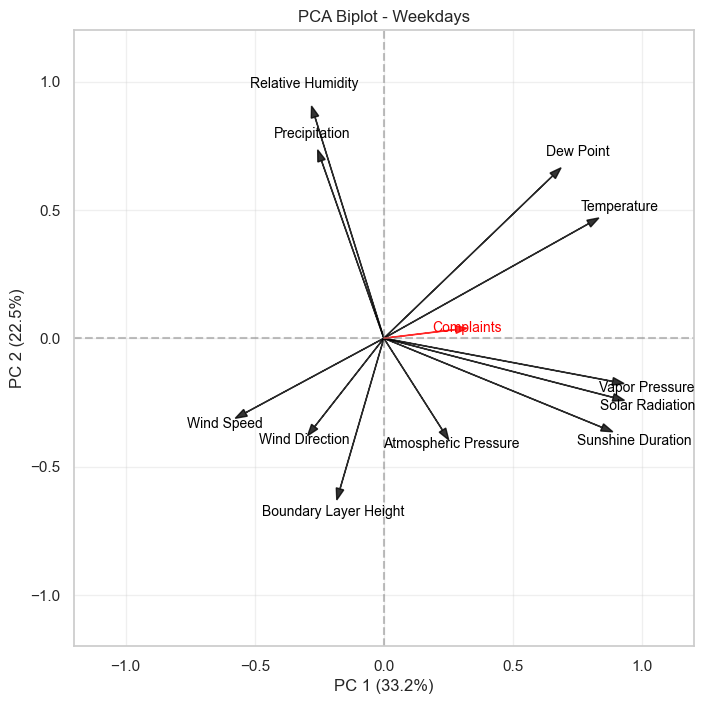

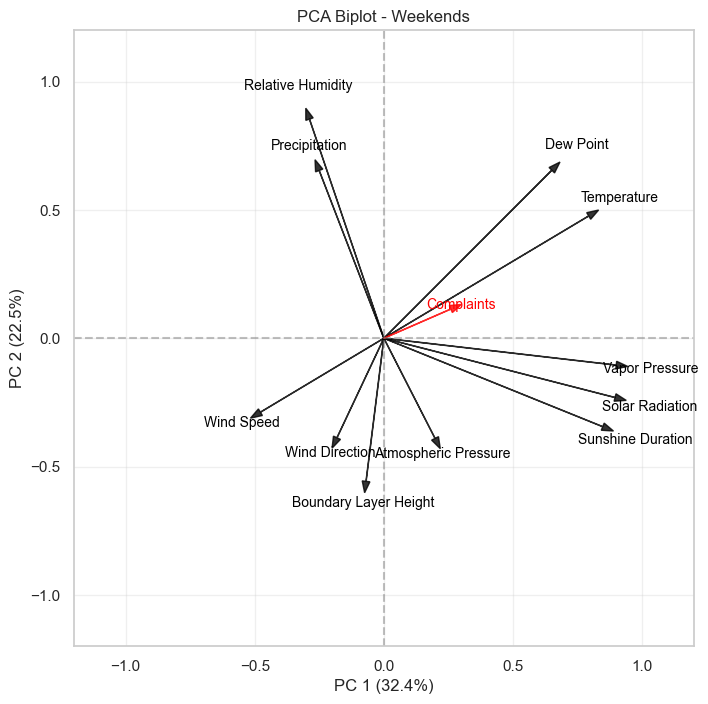

In [9]:
def plot_pca_biplot(data, title):
    """
    Conduct Principal Component Analysis (PCA) on weather variables and complaints,
    standardize the data, and render a loading biplot demonstrating feature alignment.

    Parameters:
    ----------
    data : pandas.DataFrame
        Dataframe containing meteorological variables and complaint counts.
    title : str
        Plot title string.

    Returns:
    -------
    None
        Generates and displays the matplotlib figure.
    """
    features = meteo_vars + ['complaints']

    # Drop rows containing missing values in the target feature columns
    clean_data = data[features].dropna()

    # Standardize data prior to PCA fitting
    x = StandardScaler().fit_transform(clean_data)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(x)

    # Calculate loading vectors for mapping columns onto PC1/PC2 space
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    plt.figure(figsize=(8, 8))

    # Plot feature vectors as arrows
    for i, feature in enumerate(features):
        color = 'red' if feature == 'complaints' else 'black'
        plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color=color, alpha=0.8, head_width=0.03)
        plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature.replace('_', ' ').title(),
                 color=color, ha='center', va='center', fontsize=10)

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

# Perform separate PCA decomposition on weekday vs weekend records as in publication
plot_pca_biplot(df_weekday, 'PCA Biplot - Weekdays')
plot_pca_biplot(df_weekend, 'PCA Biplot - Weekends')


## 6. Zipcode-Level Meteorological Analysis


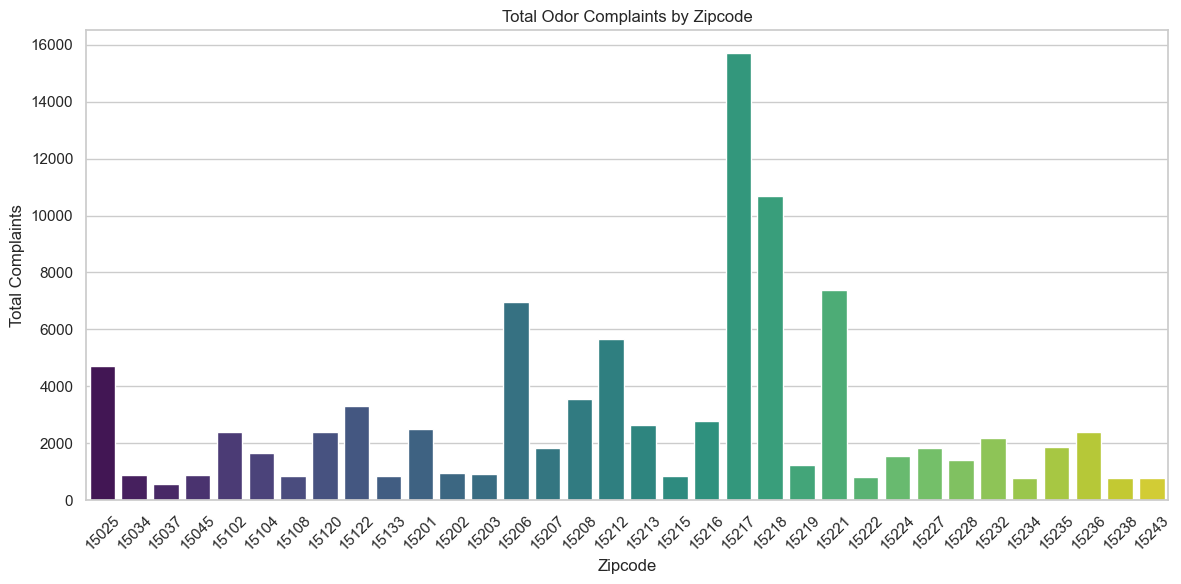

In [10]:
zipcode_complaints = df_zipcode.groupby('zipcode')['complaints'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='zipcode', y='complaints', data=zipcode_complaints, palette='viridis')
plt.title('Total Odor Complaints by Zipcode')
plt.xticks(rotation=45)
plt.xlabel('Zipcode')
plt.ylabel('Total Complaints')
plt.tight_layout()
plt.show()


### 6.2 Zipcode-Specific Pearson Correlation Matrices


Analyzing 34 zipcodes with >= 10 complaints.


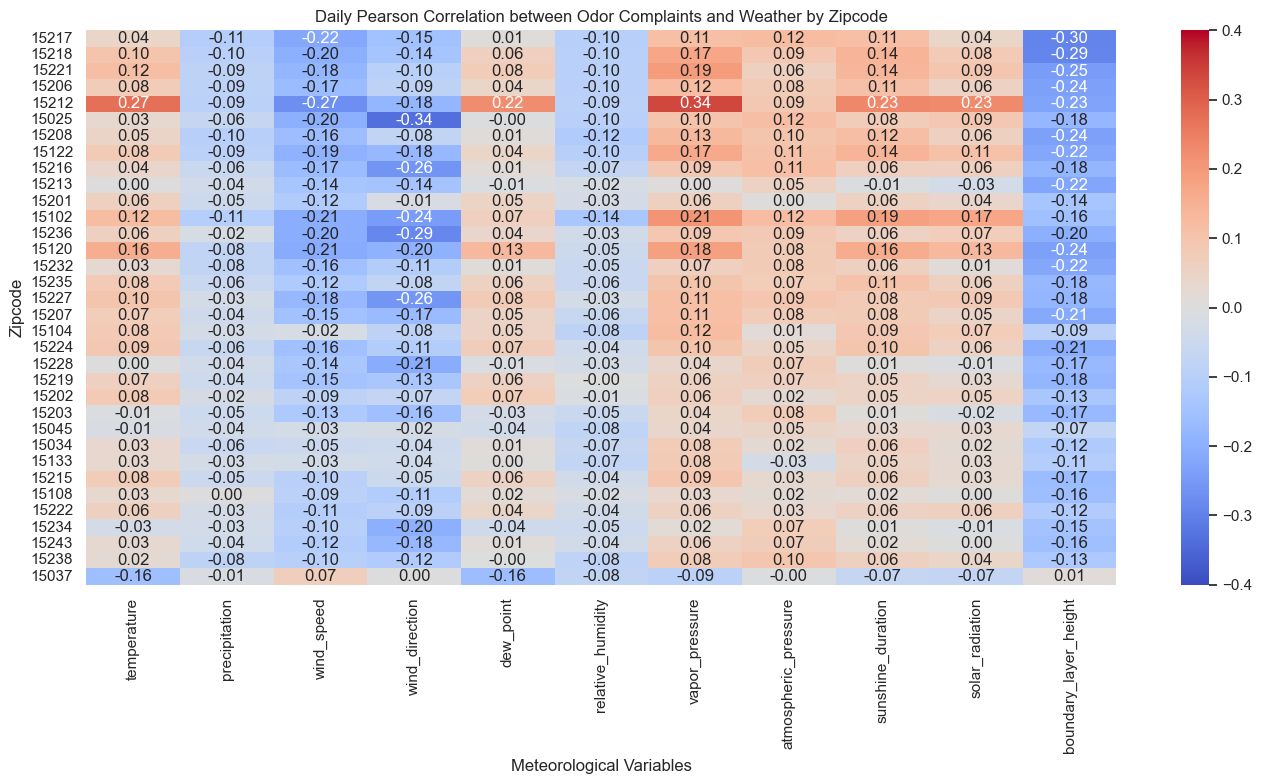

In [11]:
# Daily Correlations by Zipcode
valid_zips = zipcode_complaints[zipcode_complaints['complaints'] >= 10]['zipcode'].tolist()
print(f"Analyzing {len(valid_zips)} zipcodes with >= 10 complaints.")
meteo_vars = ['temperature', 'precipitation', 'wind_speed', 'wind_direction',
              'dew_point', 'relative_humidity', 'vapor_pressure',
              'atmospheric_pressure', 'sunshine_duration', 'solar_radiation', 'boundary_layer_height']

daily_results = []
for zip_code in valid_zips:
    df_zip_hourly = df_zipcode[df_zipcode['zipcode'] == zip_code].copy()
    df_zip_hourly['date'] = df_zip_hourly['datetime'].dt.date
    df_zip_daily = df_zip_hourly.groupby('date').agg({
        'complaints': 'sum',
        'temperature': 'mean',
        'precipitation': 'sum',
        'wind_speed': 'mean',
        'wind_direction': 'mean',
        'dew_point': 'mean',
        'relative_humidity': 'mean',
        'vapor_pressure': 'mean',
        'atmospheric_pressure': 'mean',
        'sunshine_duration': 'sum',
        'solar_radiation': 'mean',
        'boundary_layer_height': 'mean'
    }).reset_index()

    zip_corrs = {'zipcode': zip_code}
    for var in meteo_vars:
        clean_df = df_zip_daily[['complaints', var]].dropna()
        if len(clean_df) < 3 or clean_df[var].std() == 0 or clean_df['complaints'].std() == 0:
            r = np.nan
        else:
            r, _ = pearsonr(clean_df['complaints'], clean_df[var])
        zip_corrs[var] = r
    daily_results.append(zip_corrs)

df_daily_corr = pd.DataFrame(daily_results).set_index('zipcode')

plt.figure(figsize=(14, 8))
sns.heatmap(df_daily_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-0.4, vmax=0.4)
plt.title('Daily Pearson Correlation between Odor Complaints and Weather by Zipcode')
plt.xlabel('Meteorological Variables')
plt.ylabel('Zipcode')
plt.tight_layout()
plt.show()


### 6.3 Local Wind Direction Analysis


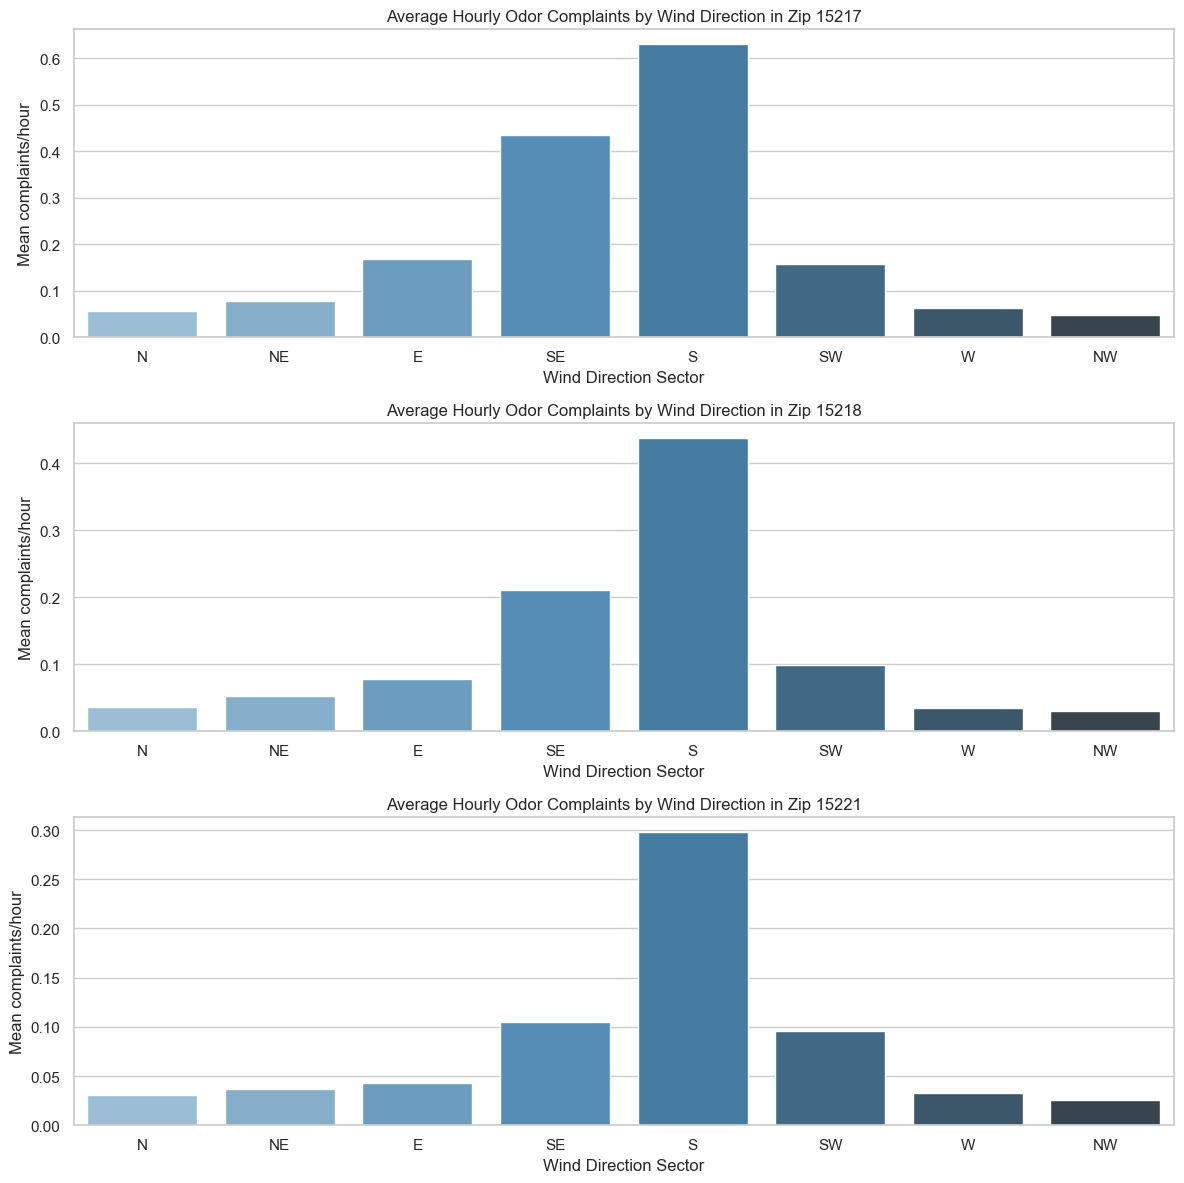

In [12]:
top_3_zips = valid_zips[:3]

def get_wind_sector(degree):
    """
    Convert wind direction degrees (0-360) into standard categorical compass sectors.

    Parameters:
    ----------
    degree : float or int
        Wind direction measurement in degrees.

    Returns:
    -------
    str or np.nan
        One of the 8 compass sector abbreviation strings, or NaN if input is NaN.
    """
    if pd.isna(degree):
        return np.nan
    sectors = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    # Apply 22.5 degree offset to center bins, map to 8 bins of 45 degrees
    idx = int(((degree + 22.5) % 360) / 45)
    return sectors[idx]

# Categorize raw wind direction degrees into sector names
df_zipcode['wind_sector'] = df_zipcode['wind_direction'].apply(get_wind_sector)

fig, axes = plt.subplots(len(top_3_zips), 1, figsize=(12, 4 * len(top_3_zips)), sharex=False)
if len(top_3_zips) == 1:
    axes = [axes]

# Plot average hourly complaints for the top 3 reporting ZIP codes
for idx, zip_code in enumerate(top_3_zips):
    df_zip = df_zipcode[df_zipcode['zipcode'] == zip_code]
    sector_complaints = df_zip.groupby('wind_sector')['complaints'].mean().reindex(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])

    ax = axes[idx]
    sns.barplot(x=sector_complaints.index, y=sector_complaints.values, ax=ax, palette='Blues_d')
    ax.set_title(f'Average Hourly Odor Complaints by Wind Direction in Zip {zip_code}')
    ax.set_ylabel('Mean complaints/hour')
    ax.set_xlabel('Wind Direction Sector')

plt.tight_layout()
plt.show()


### 6.4 Temporal Heatmap of Complaints by Zipcode


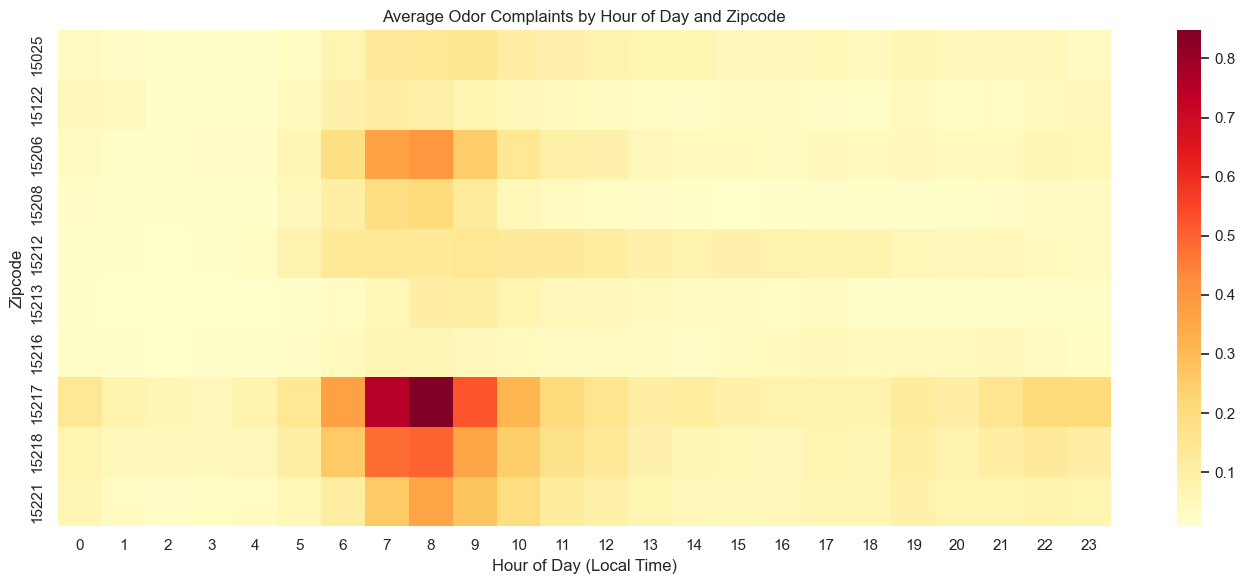

In [13]:
top_10_zips = valid_zips[:10]
df_top_10 = df_zipcode[df_zipcode['zipcode'].isin(top_10_zips)].copy()
df_top_10['hour'] = df_top_10['datetime'].dt.hour

pivot_df = df_top_10.pivot_table(index='zipcode', columns='hour', values='complaints', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_df, cmap='YlOrRd', annot=False)
plt.title('Average Odor Complaints by Hour of Day and Zipcode')
plt.xlabel('Hour of Day (Local Time)')
plt.ylabel('Zipcode')
plt.tight_layout()
plt.show()


## 7. Advanced Non-Linear Meteorological Modeling


In [14]:
df_cool = daily_df[daily_df['temperature'] <= 50].copy()
df_hot = daily_df[daily_df['temperature'] > 50].copy()

print(f"Cool Days (<= 50°F) N: {len(df_cool)}")
print(f"Hot Days (> 50°F) N: {len(df_hot)}")

results_cool = []
results_hot = []

for var in meteo_vars:
    if len(df_cool) >= 2 and df_cool[var].std() > 0 and df_cool['complaints'].std() > 0:
        r_c, p_c = pearsonr(df_cool['complaints'], df_cool[var])
    else:
        r_c, p_c = np.nan, np.nan

    if len(df_hot) >= 2 and df_hot[var].std() > 0 and df_hot['complaints'].std() > 0:
        r_h, p_h = pearsonr(df_hot['complaints'], df_hot[var])
    else:
        r_h, p_h = np.nan, np.nan

    results_cool.append({'Variable': var.replace('_', ' ').title(), 'Cool r': r_c, 'Cool p-val': p_c})
    results_hot.append({'Variable': var.replace('_', ' ').title(), 'Hot r': r_h, 'Hot p-val': p_h})

df_cool_corr = pd.DataFrame(results_cool)
df_hot_corr = pd.DataFrame(results_hot)

df_piecewise = df_cool_corr.merge(df_hot_corr, on='Variable')
print(df_piecewise.round(3))


Cool Days (<= 50°F) N: 1367
Hot Days (> 50°F) N: 1713
                 Variable  Cool r  Cool p-val  Hot r  Hot p-val
0             Temperature   0.209       0.000 -0.119      0.000
1           Precipitation  -0.012       0.645 -0.210      0.000
2              Wind Speed  -0.296       0.000 -0.160      0.000
3          Wind Direction  -0.294       0.000 -0.129      0.000
4               Dew Point   0.149       0.000 -0.223      0.000
5       Relative Humidity  -0.033       0.219 -0.243      0.000
6          Vapor Pressure   0.234       0.000  0.166      0.000
7    Atmospheric Pressure   0.090       0.001  0.203      0.000
8       Sunshine Duration   0.127       0.000  0.115      0.000
9         Solar Radiation   0.064       0.018  0.042      0.081
10  Boundary Layer Height  -0.413       0.000 -0.202      0.000


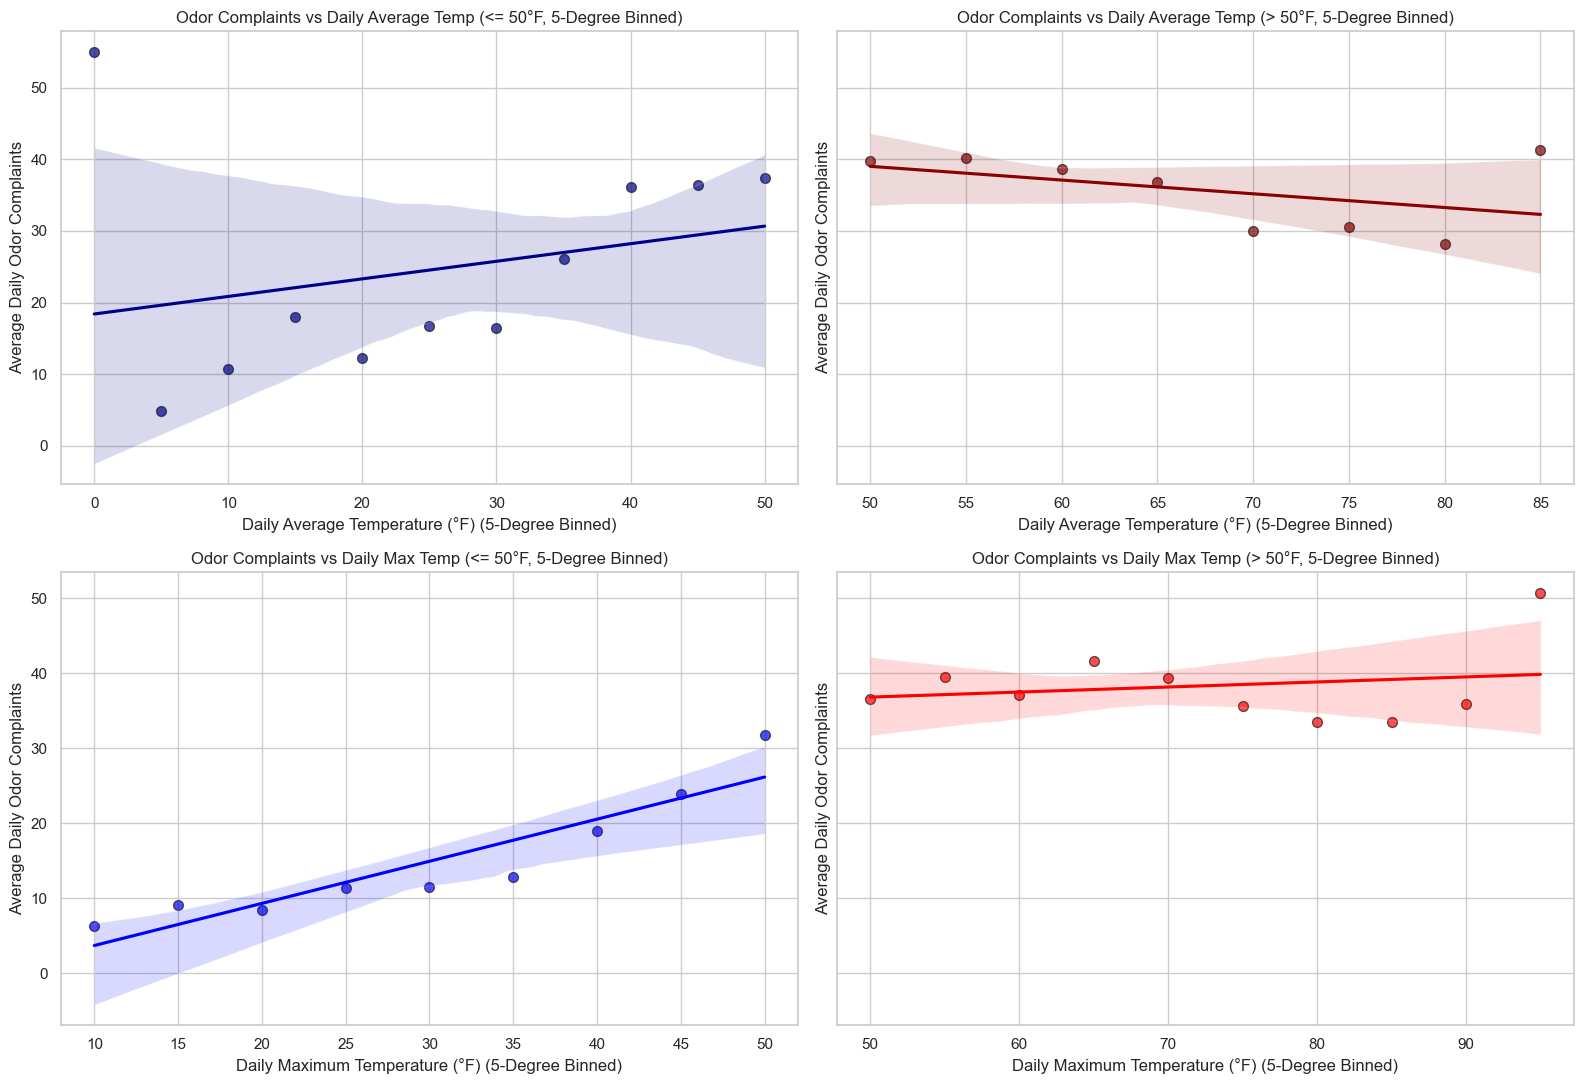

In [15]:
# Plot piecewise regressions for Temperature with 5-degree binning and 50°F split
# Row 1: Daily Average Temperature, Row 2: Daily Maximum Temperature
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey='row')

# --- Row 1: Daily Average Temperature ---
# Calculate binned daily average rates for cool days (Mean Temp <= 50°F)
binned_cool = df_cool.groupby('temperature_binned').agg(
    avg_complaints=('complaints', 'mean'),
    num_days=('complaints', 'count')
).reset_index()
binned_cool = binned_cool[binned_cool['num_days'] >= 1]

sns.regplot(x='temperature_binned', y='avg_complaints', data=binned_cool, ax=axes[0, 0], color='darkblue', 
            scatter_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k'})
axes[0, 0].set_title('Odor Complaints vs Daily Average Temp (<= 50°F, 5-Degree Binned)')
axes[0, 0].set_xlabel('Daily Average Temperature (°F) (5-Degree Binned)')
axes[0, 0].set_ylabel('Average Daily Odor Complaints')

# Calculate binned daily average rates for hot days (Mean Temp > 50°F)
binned_hot = df_hot.groupby('temperature_binned').agg(
    avg_complaints=('complaints', 'mean'),
    num_days=('complaints', 'count')
).reset_index()
binned_hot = binned_hot[binned_hot['num_days'] >= 1]

sns.regplot(x='temperature_binned', y='avg_complaints', data=binned_hot, ax=axes[0, 1], color='darkred', 
            scatter_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k'})
axes[0, 1].set_title('Odor Complaints vs Daily Average Temp (> 50°F, 5-Degree Binned)')
axes[0, 1].set_xlabel('Daily Average Temperature (°F) (5-Degree Binned)')
axes[0, 1].set_ylabel('Average Daily Odor Complaints')


# --- Row 2: Daily Maximum Temperature ---
# We bin maximum daily temperature in the same way (5-degree bins)
daily_df['temp_max_binned'] = (daily_df['temp_max'] / 5).round() * 5

# Split by max temperature (<= 50°F vs > 50°F)
df_max_cool = daily_df[daily_df['temp_max'] <= 50].copy()
df_max_hot = daily_df[daily_df['temp_max'] > 50].copy()

# Calculate binned daily max rates for cool days (Max Temp <= 50°F)
binned_max_cool = df_max_cool.groupby('temp_max_binned').agg(
    avg_complaints=('complaints', 'mean'),
    num_days=('complaints', 'count')
).reset_index()
binned_max_cool = binned_max_cool[binned_max_cool['num_days'] >= 1]

sns.regplot(x='temp_max_binned', y='avg_complaints', data=binned_max_cool, ax=axes[1, 0], color='blue', 
            scatter_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k'})
axes[1, 0].set_title('Odor Complaints vs Daily Max Temp (<= 50°F, 5-Degree Binned)')
axes[1, 0].set_xlabel('Daily Maximum Temperature (°F) (5-Degree Binned)')
axes[1, 0].set_ylabel('Average Daily Odor Complaints')

# Calculate binned daily max rates for hot days (Max Temp > 50°F)
binned_max_hot = df_max_hot.groupby('temp_max_binned').agg(
    avg_complaints=('complaints', 'mean'),
    num_days=('complaints', 'count')
).reset_index()
binned_max_hot = binned_max_hot[binned_max_hot['num_days'] >= 1]

sns.regplot(x='temp_max_binned', y='avg_complaints', data=binned_max_hot, ax=axes[1, 1], color='red', 
            scatter_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k'})
axes[1, 1].set_title('Odor Complaints vs Daily Max Temp (> 50°F, 5-Degree Binned)')
axes[1, 1].set_xlabel('Daily Maximum Temperature (°F) (5-Degree Binned)')
axes[1, 1].set_ylabel('Average Daily Odor Complaints')

plt.tight_layout()
plt.show()

## 8. Continuous Modeling, Inversion Analysis, and the Odor Risk Index (ORI)


In [16]:
import statsmodels.api as sm

# Selected variables for modeling (including is_weekend to control for weekly reporting shifts)
model_vars = ['temperature', 'temperature_squared', 'solar_radiation', 'relative_humidity',
              'wind_speed', 'precipitation', 'diurnal_temperature_range',
              'boundary_layer_height', 'atmospheric_pressure', 'is_weekend']

daily_df['temperature_squared'] = daily_df['temperature'] ** 2
daily_df['is_weekend'] = daily_df['is_weekend'].astype(int)

# Clean data for count models
binned_cols = [c for c in daily_df.columns if c.endswith('_binned')]
df_count = daily_df[['complaints'] + model_vars + binned_cols].dropna()
X_count = df_count[model_vars]
X_count = sm.add_constant(X_count)
y_count = df_count['complaints']

# 1. OLS Linear Regression
ols_model = sm.OLS(y_count, X_count)
ols_res = ols_model.fit()
print("=== OLS Linear Regression Results (Daily Complaints Count) ===")
print(ols_res.summary())

# 2. Poisson Regression
poisson_model = sm.GLM(y_count, X_count, family=sm.families.Poisson())
poisson_res = poisson_model.fit()
print("\n=== Poisson Regression Results (Daily Complaints Count) ===")
print(poisson_res.summary())


=== OLS Linear Regression Results (Daily Complaints Count) ===
                            OLS Regression Results                            
Dep. Variable:             complaints   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     153.4
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          2.30e-261
Time:                        14:47:29   Log-Likelihood:                -14952.
No. Observations:                3080   AIC:                         2.993e+04
Df Residuals:                    3069   BIC:                         2.999e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

### 8.2 Daily Odor Severity Prediction (Average Smell Value)


In [17]:
# Filter active days
df_severity = daily_df[daily_df['complaints'] > 0][['smell_value_average'] + model_vars].dropna()

X_sev = df_severity[model_vars]
X_sev = sm.add_constant(X_sev)
y_sev = df_severity['smell_value_average']

# Fit OLS severity model
severity_model = sm.OLS(y_sev, X_sev)
severity_res = severity_model.fit()
print("=== OLS Regression Results (Daily average smell severity 1-5 scale) ===")
print(severity_res.summary())


=== OLS Regression Results (Daily average smell severity 1-5 scale) ===
                             OLS Regression Results                            
Dep. Variable:     smell_value_average   R-squared:                       0.166
Model:                             OLS   Adj. R-squared:                  0.163
Method:                  Least Squares   F-statistic:                     60.79
Date:                 Thu, 25 Jun 2026   Prob (F-statistic):          7.16e-113
Time:                         14:47:29   Log-Likelihood:                -2420.4
No. Observations:                 3066   AIC:                             4863.
Df Residuals:                     3055   BIC:                             4929.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

### 8.3 Severity-Weighted Odor Risk Index (Logit)


In [18]:
# Define binary event
# Weighted Odor Burden: combines complaint count with average severity
daily_df['weighted_odor_burden'] = daily_df['complaints'] * daily_df['smell_value_average'].fillna(0)
odor_burden_threshold = daily_df['weighted_odor_burden'].mean()
daily_df['is_odor_event'] = (daily_df['weighted_odor_burden'] > odor_burden_threshold).astype(int)
print(f"Odor event threshold (mean weighted odor burden): {odor_burden_threshold:.1f}")
print(f"Days classified as odor events: {daily_df['is_odor_event'].sum()} / {len(daily_df)} ({daily_df['is_odor_event'].mean()*100:.1f}%)")

df_logit = daily_df[['is_odor_event'] + model_vars].dropna()
X_logit = df_logit[model_vars]
X_logit = sm.add_constant(X_logit)
y_logit = df_logit['is_odor_event']

logit_model = sm.Logit(y_logit, X_logit)
logit_res = logit_model.fit()
print("=== Logit Regression Results for Severity-Weighted Odor Risk Index ===")
print(logit_res.summary())

# Display Odds Ratios
odds_ratios = np.exp(logit_res.params)
df_odds = pd.DataFrame({
    'Odds Ratio (OR)': odds_ratios,
    'Lower CI (95%)': np.exp(logit_res.conf_int()[0]),
    'Upper CI (95%)': np.exp(logit_res.conf_int()[1]),
    'p-value': logit_res.pvalues
})
print("\n--- Odds Ratios ---")
print(df_odds.round(4))

# Calculate daily ORI:
# 1. Raw prediction (with temporal/weekend adjustments included)
daily_df['odor_risk_index_raw'] = logit_res.predict(X_logit) * 100

# 2. De-biased prediction (with all temporal dummies set to 0.0, assuming continuous 24/7 operations)
X_logit_debiased = X_logit.copy()
temporal_cols = ['dow_tue', 'dow_wed', 'dow_thu', 'dow_fri', 'dow_sat', 'dow_sun', 'is_holiday']
for col in temporal_cols:
    if col in X_logit_debiased.columns:
        X_logit_debiased[col] = 0.0
daily_df['odor_risk_index'] = logit_res.predict(X_logit_debiased) * 100

# Calculate classification and accuracy metrics for both raw and de-biased models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix

y_actual = y_logit
y_prob_raw = daily_df['odor_risk_index_raw'].dropna() / 100.0
y_prob_debiased = daily_df['odor_risk_index'].dropna() / 100.0
base_rate = y_actual.mean()

print("\n=== Logit Model Classification Performance Metrics ===")
print(f"Total days analyzed: {len(y_actual)}")
print(f"Historical base rate (prevalence) of odor events: {base_rate*100:.2f}%")
print("-" * 50)

for name, y_prob in [("ODOR COMPLAINT FORECAST", y_prob_raw), ("METEOROLOGICAL ODOR RISK INDEX (NORMALIZED)", y_prob_debiased)]:
    print(f"\n>>> METRICS FOR {name} <<<")
    
    # Evaluate at 50% threshold
    y_pred_50 = (y_prob >= 0.50).astype(int)
    cm_50 = confusion_matrix(y_actual, y_pred_50)
    tn_50, fp_50, fn_50, tp_50 = cm_50.ravel()
    accuracy_50 = accuracy_score(y_actual, y_pred_50)
    precision_50 = precision_score(y_actual, y_pred_50, zero_division=0)
    recall_50 = recall_score(y_actual, y_pred_50)
    f1_50 = f1_score(y_actual, y_pred_50)
    
    print("  THRESHOLD: 50.0%")
    print(f"  Confusion Matrix:\n    TN: {tn_50} | FP: {fp_50}\n    FN: {fn_50} | TP: {tp_50}")
    print(f"  Accuracy:  {accuracy_50*100:.2f}%")
    print(f"  Precision: {precision_50*100:.2f}%")
    print(f"  Recall:    {recall_50*100:.2f}%")
    print(f"  F1-Score:  {f1_50:.3f}")
    print("  " + "-" * 30)
    
    # Evaluate at base rate threshold
    y_pred_br = (y_prob >= base_rate).astype(int)
    cm_br = confusion_matrix(y_actual, y_pred_br)
    tn_br, fp_br, fn_br, tp_br = cm_br.ravel()
    accuracy_br = accuracy_score(y_actual, y_pred_br)
    precision_br = precision_score(y_actual, y_pred_br, zero_division=0)
    recall_br = recall_score(y_actual, y_pred_br)
    f1_br = f1_score(y_actual, y_pred_br)
    
    print(f"  THRESHOLD: {base_rate*100:.1f}% (Base-Rate)")
    print(f"  Confusion Matrix:\n    TN: {tn_br} | FP: {fp_br}\n    FN: {fn_br} | TP: {tp_br}")
    print(f"  Accuracy:  {accuracy_br*100:.2f}%")
    print(f"  Precision: {precision_br*100:.2f}%")
    print(f"  Recall:    {recall_br*100:.2f}%")
    print(f"  F1-Score:  {f1_br:.3f}")
    print("  " + "-" * 30)
    
    auc = roc_auc_score(y_actual, y_prob)
    brier = brier_score_loss(y_actual, y_prob)
    print(f"  Discrimination Power (ROC-AUC): {auc:.4f}")
    print(f"  Overall Forecast Error (Brier Score): {brier:.4f}")
    print("-" * 50)
print("======================================================")

Odor event threshold (mean weighted odor burden): 117.2
Days classified as odor events: 871 / 3080 (28.3%)
Optimization terminated successfully.
         Current function value: 0.392246
         Iterations 7
=== Logit Regression Results for Severity-Weighted Odor Risk Index ===
                           Logit Regression Results                           
Dep. Variable:          is_odor_event   No. Observations:                 3080
Model:                          Logit   Df Residuals:                     3069
Method:                           MLE   Df Model:                           10
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.3414
Time:                        14:47:29   Log-Likelihood:                -1208.1
converged:                       True   LL-Null:                       -1834.4
Covariance Type:            nonrobust   LLR p-value:                6.864e-263
                                coef    std err          z      P>|z|      [0.025      0

### 8.4 Visualizing the Probability of Odor Events


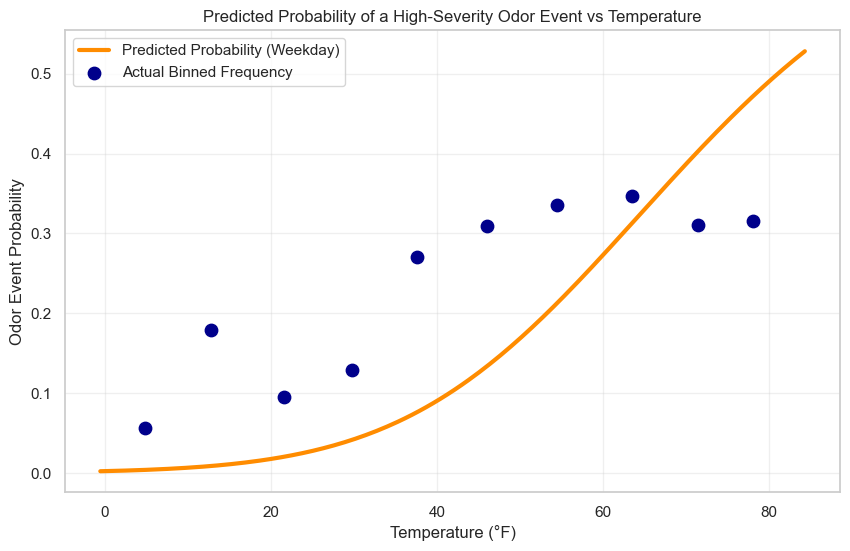

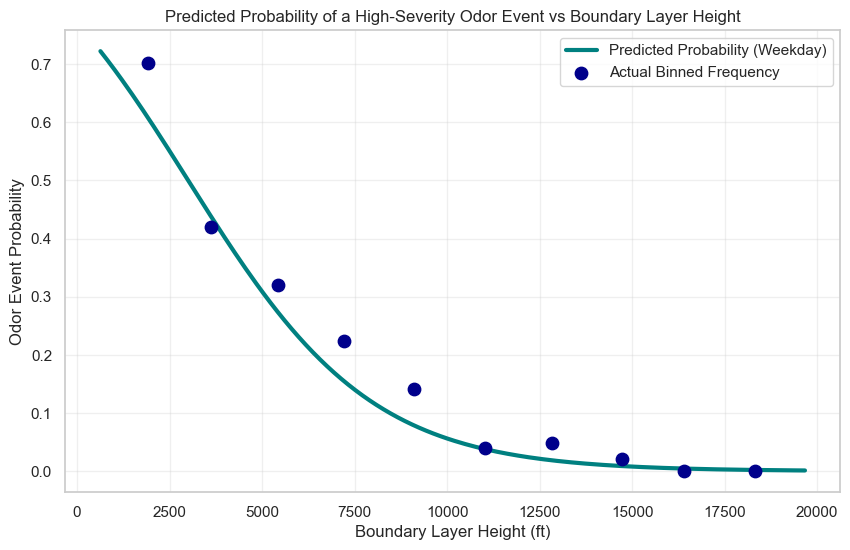

In [19]:
# Generate a range of temperatures
temp_range = np.linspace(daily_df['temperature'].min(), daily_df['temperature'].max(), 200)

# Create a prediction dataframe holding other variables at their mean
pred_df = pd.DataFrame({
    'const': 1.0,
    'temperature': temp_range,
    'temperature_squared': temp_range ** 2,
    'solar_radiation': daily_df['solar_radiation'].mean(),
    'relative_humidity': daily_df['relative_humidity'].mean(),
    'wind_speed': daily_df['wind_speed'].mean(),
    'precipitation': daily_df['precipitation'].mean(),
    'diurnal_temperature_range': daily_df['diurnal_temperature_range'].mean(),
    'boundary_layer_height': daily_df['boundary_layer_height'].mean(),
    'atmospheric_pressure': daily_df['atmospheric_pressure'].mean(),
    'is_weekend': 0.0 # Holding weekend at 0 (weekday baseline) for the curve
})

# Predict probabilities
pred_probs = logit_res.predict(pred_df)

plt.figure(figsize=(10, 6))
plt.plot(temp_range, pred_probs, color='darkorange', linewidth=3, label='Predicted Probability (Weekday)')

# Add actual scatter points (binned by temperature equal-width bins)
# Bin temperature into 10 equal-width bins across the observed range to show the U-shape curve cleanly
temp_bins = pd.cut(daily_df['temperature'], bins=10)
binned_events = daily_df.groupby(temp_bins, observed=False).agg({
    'temperature': 'mean',
    'is_odor_event': 'mean'
})
plt.scatter(binned_events['temperature'], binned_events['is_odor_event'], color='darkblue', s=80, zorder=5, label='Actual Binned Frequency')

plt.title('Predicted Probability of a High-Severity Odor Event vs Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Odor Event Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Odor Event Probability vs. Boundary Layer Height
# Generate a range of boundary layer heights
blh_range = np.linspace(daily_df['boundary_layer_height'].min(), daily_df['boundary_layer_height'].max(), 200)

pred_df_blh = pd.DataFrame({
    'const': 1.0,
    'temperature': daily_df['temperature'].mean(),
    'temperature_squared': daily_df['temperature'].mean() ** 2,
    'solar_radiation': daily_df['solar_radiation'].mean(),
    'relative_humidity': daily_df['relative_humidity'].mean(),
    'wind_speed': daily_df['wind_speed'].mean(),
    'precipitation': daily_df['precipitation'].mean(),
    'diurnal_temperature_range': daily_df['diurnal_temperature_range'].mean(),
    'boundary_layer_height': blh_range,
    'atmospheric_pressure': daily_df['atmospheric_pressure'].mean(),
    'is_weekend': 0.0
})

pred_probs_blh = logit_res.predict(pred_df_blh)

plt.figure(figsize=(10, 6))
plt.plot(blh_range, pred_probs_blh, color='teal', linewidth=3, label='Predicted Probability (Weekday)')

# Add actual scatter points (binned by boundary layer height, equal-width bins)
valid_blh_df = daily_df.dropna(subset=['boundary_layer_height']).copy()
blh_bins = pd.cut(valid_blh_df['boundary_layer_height'], bins=10)
binned_events_blh = valid_blh_df.groupby(blh_bins, observed=False).agg({
    'boundary_layer_height': 'mean',
    'is_odor_event': 'mean'
})
plt.scatter(binned_events_blh['boundary_layer_height'], binned_events_blh['is_odor_event'], color='darkblue', s=80, zorder=5, label='Actual Binned Frequency')

plt.title('Predicted Probability of a High-Severity Odor Event vs Boundary Layer Height')
plt.xlabel('Boundary Layer Height (ft)')
plt.ylabel('Odor Event Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 8.5 Visualizing the Odor Risk Index (ORI) vs. Actual Complaints


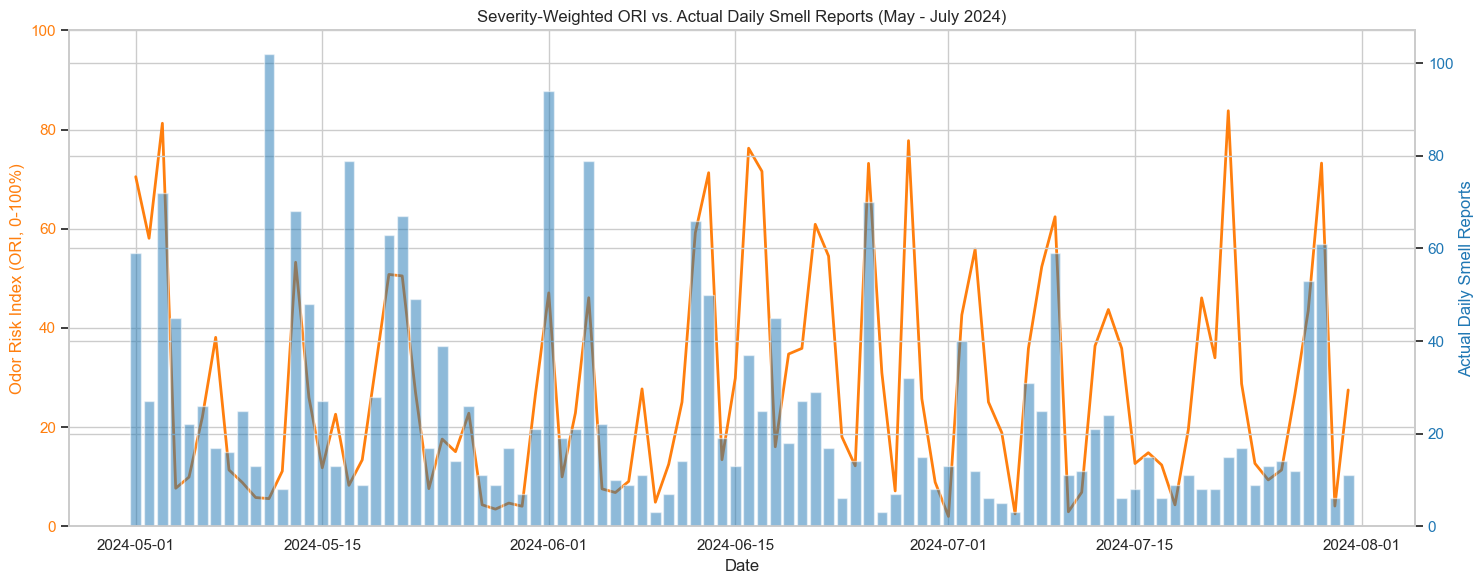

In [20]:
daily_df['date_dt'] = pd.to_datetime(daily_df['date'])
sample_df = daily_df[(daily_df['date_dt'] >= '2024-05-01') & (daily_df['date_dt'] <= '2024-07-31')].copy().sort_values('date')

fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:orange'
ax1.set_xlabel('Date')
ax1.set_ylabel('Odor Risk Index (ORI, 0-100%)', color=color)
ax1.plot(sample_df['date_dt'], sample_df['odor_risk_index'], color=color, linewidth=2, label='Odor Risk Index')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Actual Daily Smell Reports', color=color)
ax2.bar(sample_df['date_dt'], sample_df['complaints'], color=color, alpha=0.5, width=0.8, label='Actual complaints')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Severity-Weighted ORI vs. Actual Daily Smell Reports (May - July 2024)')
fig.tight_layout()
plt.show()


### 8.5b Smoothed Trend Visualization (7-Day Rolling Average)


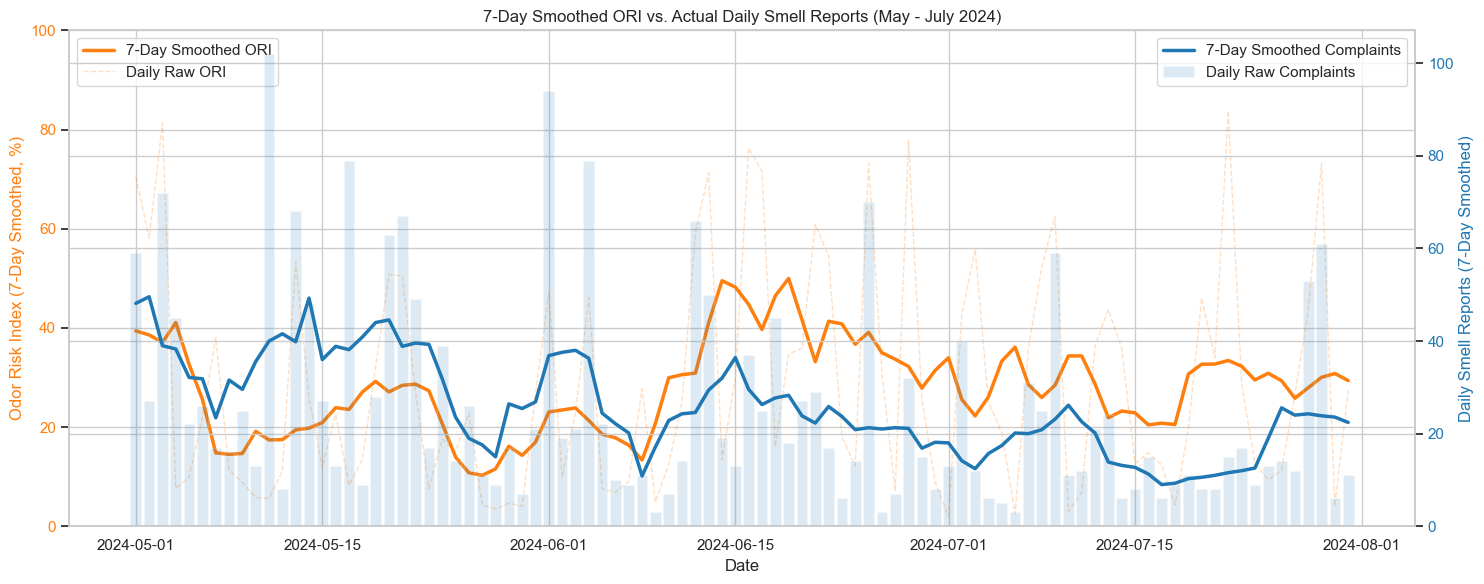

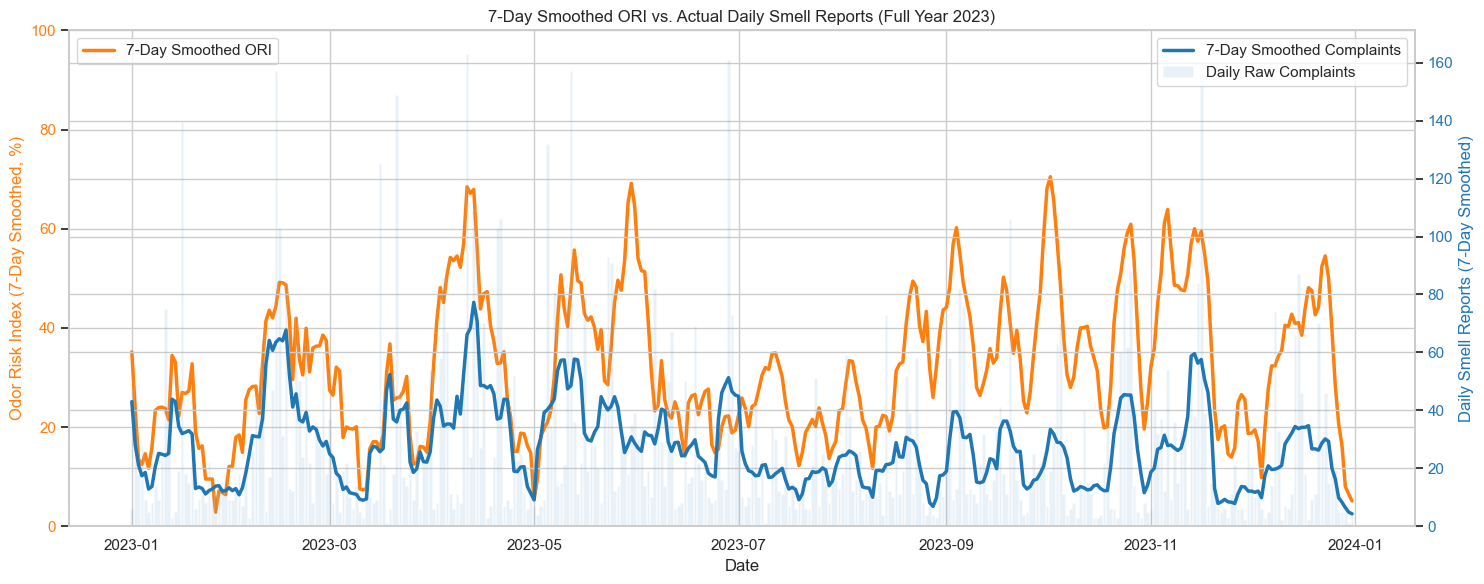

In [21]:
# Compute 7-day centered rolling averages for smoothing
daily_df['ori_smoothed'] = daily_df['odor_risk_index'].rolling(window=7, center=True, min_periods=1).mean()
daily_df['complaints_smoothed'] = daily_df['complaints'].rolling(window=7, center=True, min_periods=1).mean()

# Plot 1: Smoothed 3-month sample window (May - July 2024)
sample_3m = daily_df[(daily_df['date_dt'] >= '2024-05-01') & (daily_df['date_dt'] <= '2024-07-31')].copy().sort_values('date')

fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:orange'
ax1.set_xlabel('Date')
ax1.set_ylabel('Odor Risk Index (7-Day Smoothed, %)', color=color)
ax1.plot(sample_3m['date_dt'], sample_3m['ori_smoothed'], color=color, linewidth=2.5, label='7-Day Smoothed ORI')
ax1.plot(sample_3m['date_dt'], sample_3m['odor_risk_index'], color=color, alpha=0.25, linewidth=1, linestyle='--', label='Daily Raw ORI')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Daily Smell Reports (7-Day Smoothed)', color=color)
ax2.bar(sample_3m['date_dt'], sample_3m['complaints'], color=color, alpha=0.15, width=0.8, label='Daily Raw Complaints')
ax2.plot(sample_3m['date_dt'], sample_3m['complaints_smoothed'], color=color, linewidth=2.5, label='7-Day Smoothed Complaints')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('7-Day Smoothed ORI vs. Actual Daily Smell Reports (May - July 2024)')
fig.tight_layout()
plt.show()

# Plot 2: Smoothed Full Year 2023
sample_12m = daily_df[(daily_df['date_dt'] >= '2023-01-01') & (daily_df['date_dt'] <= '2023-12-31')].copy().sort_values('date')

fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:orange'
ax1.set_xlabel('Date')
ax1.set_ylabel('Odor Risk Index (7-Day Smoothed, %)', color=color)
ax1.plot(sample_12m['date_dt'], sample_12m['ori_smoothed'], color=color, linewidth=2.5, label='7-Day Smoothed ORI')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Daily Smell Reports (7-Day Smoothed)', color=color)
ax2.bar(sample_12m['date_dt'], sample_12m['complaints'], color=color, alpha=0.1, width=0.8, label='Daily Raw Complaints')
ax2.plot(sample_12m['date_dt'], sample_12m['complaints_smoothed'], color=color, linewidth=2.5, label='7-Day Smoothed Complaints')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('7-Day Smoothed ORI vs. Actual Daily Smell Reports (Full Year 2023)')
fig.tight_layout()
plt.show()


### 8.5c Monthly ORI Time Series


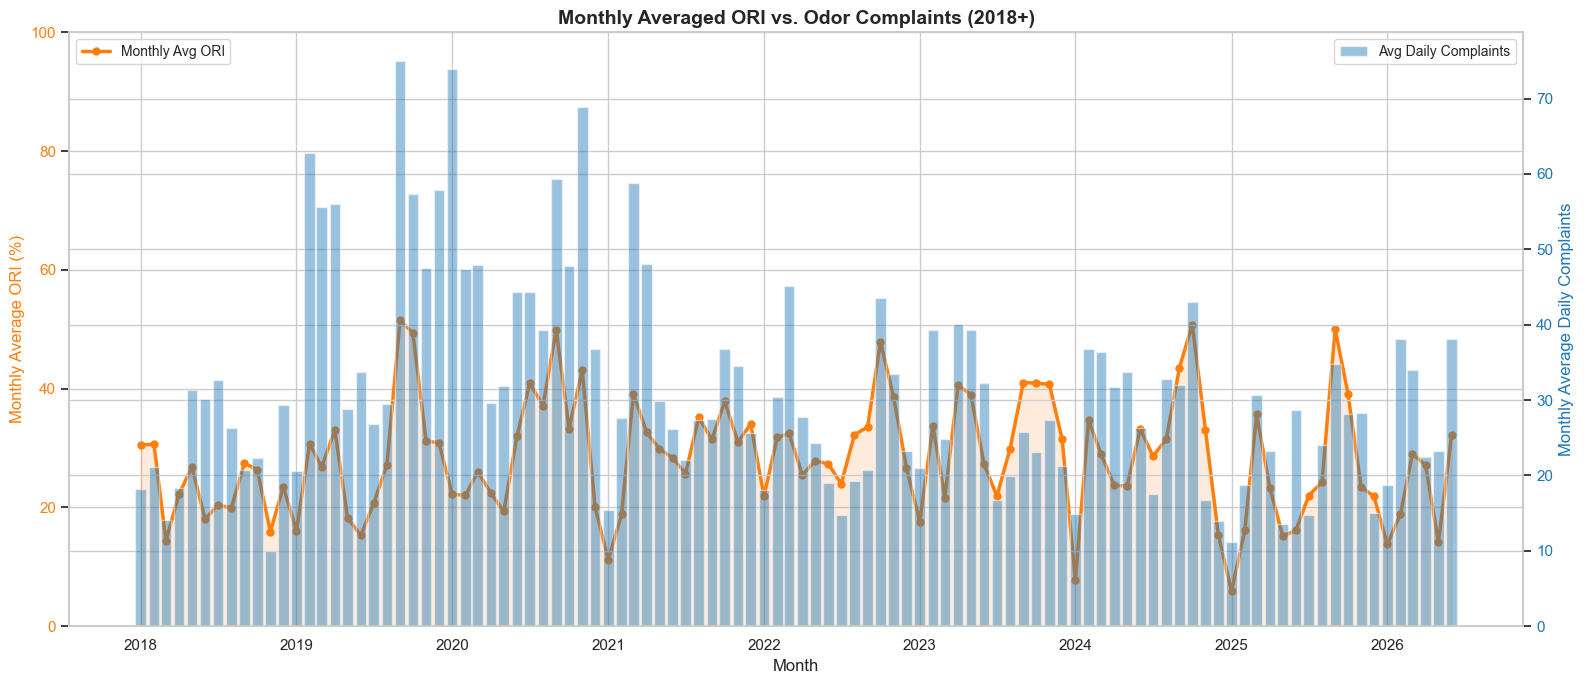

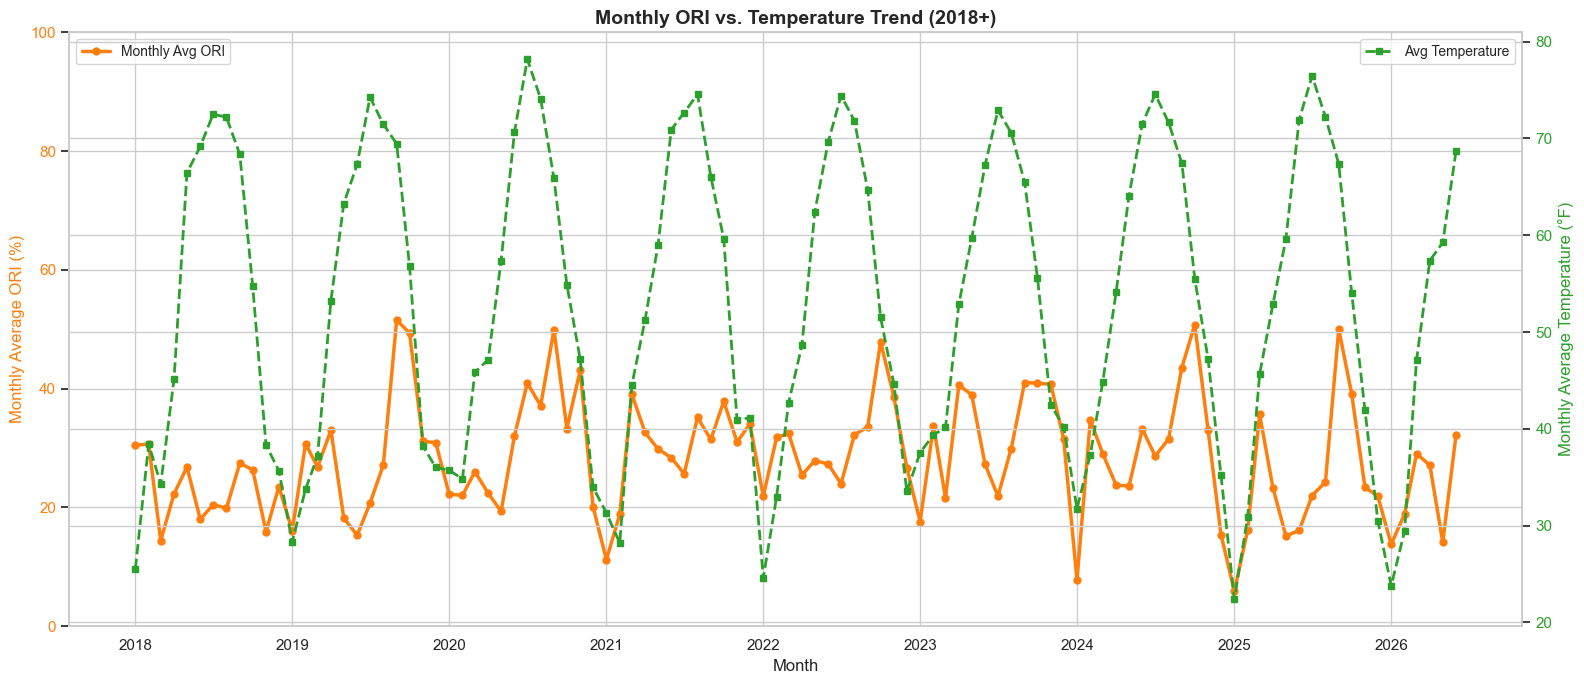

In [22]:
# Monthly ORI Time Series: Aggregates daily ORI and complaints to monthly averages
# This reveals the seasonal pattern more clearly, analogous to how the Seoul study
# used monthly aggregation to demonstrate weather-odor relationships.

# Ensure date_dt exists
if 'date_dt' not in daily_df.columns:
    daily_df['date_dt'] = pd.to_datetime(daily_df['date'])

daily_df['year_month'] = daily_df['date_dt'].dt.to_period('M')

monthly_ori = daily_df.dropna(subset=['odor_risk_index']).groupby('year_month').agg({
    'odor_risk_index': 'mean',
    'complaints': 'mean',
    'is_odor_event': 'mean',
    'temperature': 'mean'
}).reset_index()
monthly_ori['date_dt'] = monthly_ori['year_month'].dt.to_timestamp()

# Filter to 2018+ for cleaner visualization
monthly_ori = monthly_ori[monthly_ori['date_dt'] >= '2018-01-01'].copy()

fig, ax1 = plt.subplots(figsize=(16, 7))

color = 'tab:orange'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Monthly Average ORI (%)', color=color, fontsize=12)
ax1.plot(monthly_ori['date_dt'], monthly_ori['odor_risk_index'], color=color, linewidth=2.5,
         marker='o', markersize=5, label='Monthly Avg ORI')
ax1.fill_between(monthly_ori['date_dt'], 0, monthly_ori['odor_risk_index'], color=color, alpha=0.15)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)
ax1.legend(loc='upper left', fontsize=10)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Monthly Average Daily Complaints', color=color, fontsize=12)
ax2.bar(monthly_ori['date_dt'], monthly_ori['complaints'], color=color, alpha=0.45, width=25, label='Avg Daily Complaints')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right', fontsize=10)

plt.title('Monthly Averaged ORI vs. Odor Complaints (2018+)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Monthly ORI with temperature overlay to show the seasonal driver
fig, ax1 = plt.subplots(figsize=(16, 7))

color = 'tab:orange'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Monthly Average ORI (%)', color=color, fontsize=12)
ax1.plot(monthly_ori['date_dt'], monthly_ori['odor_risk_index'], color=color, linewidth=2.5,
         marker='o', markersize=5, label='Monthly Avg ORI')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Monthly Average Temperature (°F)', color=color, fontsize=12)
ax2.plot(monthly_ori['date_dt'], monthly_ori['temperature'], color=color, linewidth=2,
         marker='s', markersize=4, linestyle='--', label='Avg Temperature')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right', fontsize=10)

ax1.legend(loc='upper left', fontsize=10)
plt.title('Monthly ORI vs. Temperature Trend (2018+)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


### 8.6 Poisson Model Diagnostic: Actual vs. Predicted Calibration


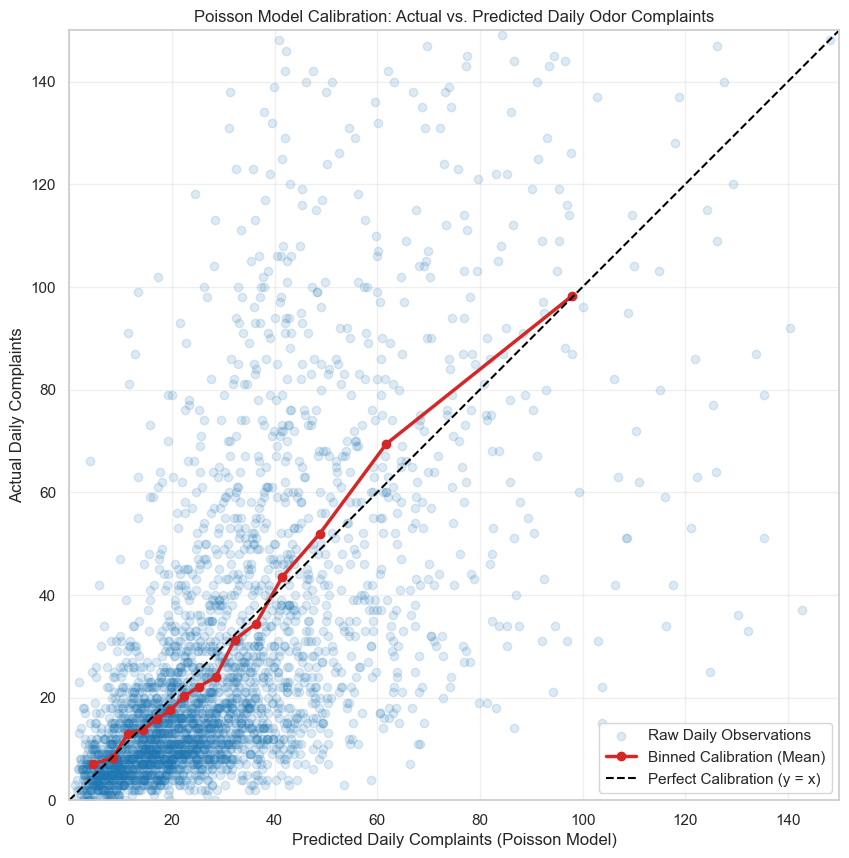

In [23]:
# Calculate predictions for the Poisson count model
# 1. Raw prediction (with temporal/weekend adjustments included)
df_count['predicted_complaints_raw'] = poisson_res.predict(X_count)
# Use raw predictions for the calibration plot (which must compare against observed raw counts)
df_count['predicted_complaints'] = df_count['predicted_complaints_raw']

# 2. De-biased prediction (with all temporal dummies set to 0.0, assuming continuous 24/7 operations)
X_count_debiased = X_count.copy()
temporal_cols = ['dow_tue', 'dow_wed', 'dow_thu', 'dow_fri', 'dow_sat', 'dow_sun', 'is_holiday']
for col in temporal_cols:
    if col in X_count_debiased.columns:
        X_count_debiased[col] = 0.0
df_count['predicted_complaints_debiased'] = poisson_res.predict(X_count_debiased)
df_count['predicted_complaints'] = poisson_res.predict(X_count)

plt.figure(figsize=(10, 10)) # Square figure for equal axes representation

# Plot raw observations with transparency to show density
plt.scatter(df_count['predicted_complaints'], df_count['complaints'], alpha=0.15, color='tab:blue', label='Raw Daily Observations')

# Create a binned calibration curve: group by predicted values using quantiles
df_count['pred_bin'] = pd.qcut(df_count['predicted_complaints'], q=15, duplicates='drop')
binned_data = df_count.groupby('pred_bin').agg({
    'predicted_complaints': 'mean',
    'complaints': 'mean'
}).reset_index()

# Plot the binned calibration line
plt.plot(binned_data['predicted_complaints'], binned_data['complaints'], color='tab:red', marker='o', linewidth=2.5, label='Binned Calibration (Mean)')

# Plot the y = x line representing perfect calibration
limit = 150
plt.plot([0, limit], [0, limit], color='black', linestyle='--', linewidth=1.5, label='Perfect Calibration (y = x)')

plt.xlim(0, limit)
plt.ylim(0, limit)
plt.gca().set_aspect('equal', adjustable='box') # Force 1:1 aspect ratio

plt.title('Poisson Model Calibration: Actual vs. Predicted Daily Odor Complaints')
plt.xlabel('Predicted Daily Complaints (Poisson Model)')
plt.ylabel('Actual Daily Complaints')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 8.6b Multivariate Model Marginal Effects Overlay

**Methodology:**
To visualize the true marginal effects of each meteorological driver from our unbinned multivariate Poisson model, we overlay the model's predictive curve onto the binned, normalized actual daily complaint rates. For each meteorological variable:
1. We generate a smooth continuous sequence of values from the variable's minimum to maximum.
2. We construct a synthetic dataset where the target variable varies along this sequence while all other covariates in the model are held constant at their respective dataset medians.
3. Crucially, when temperature varies, the quadratic term `temperature_squared` is updated dynamically as $\text{temperature}^2$ rather than being held at its median to preserve functional consistency.
4. We predict expected complaints using `poisson_res.predict()` and overlay this continuous marginal curve as a smooth line cutting through the binned historical actual rates. Y-axis limits are scaled dynamically to align both datasets perfectly.

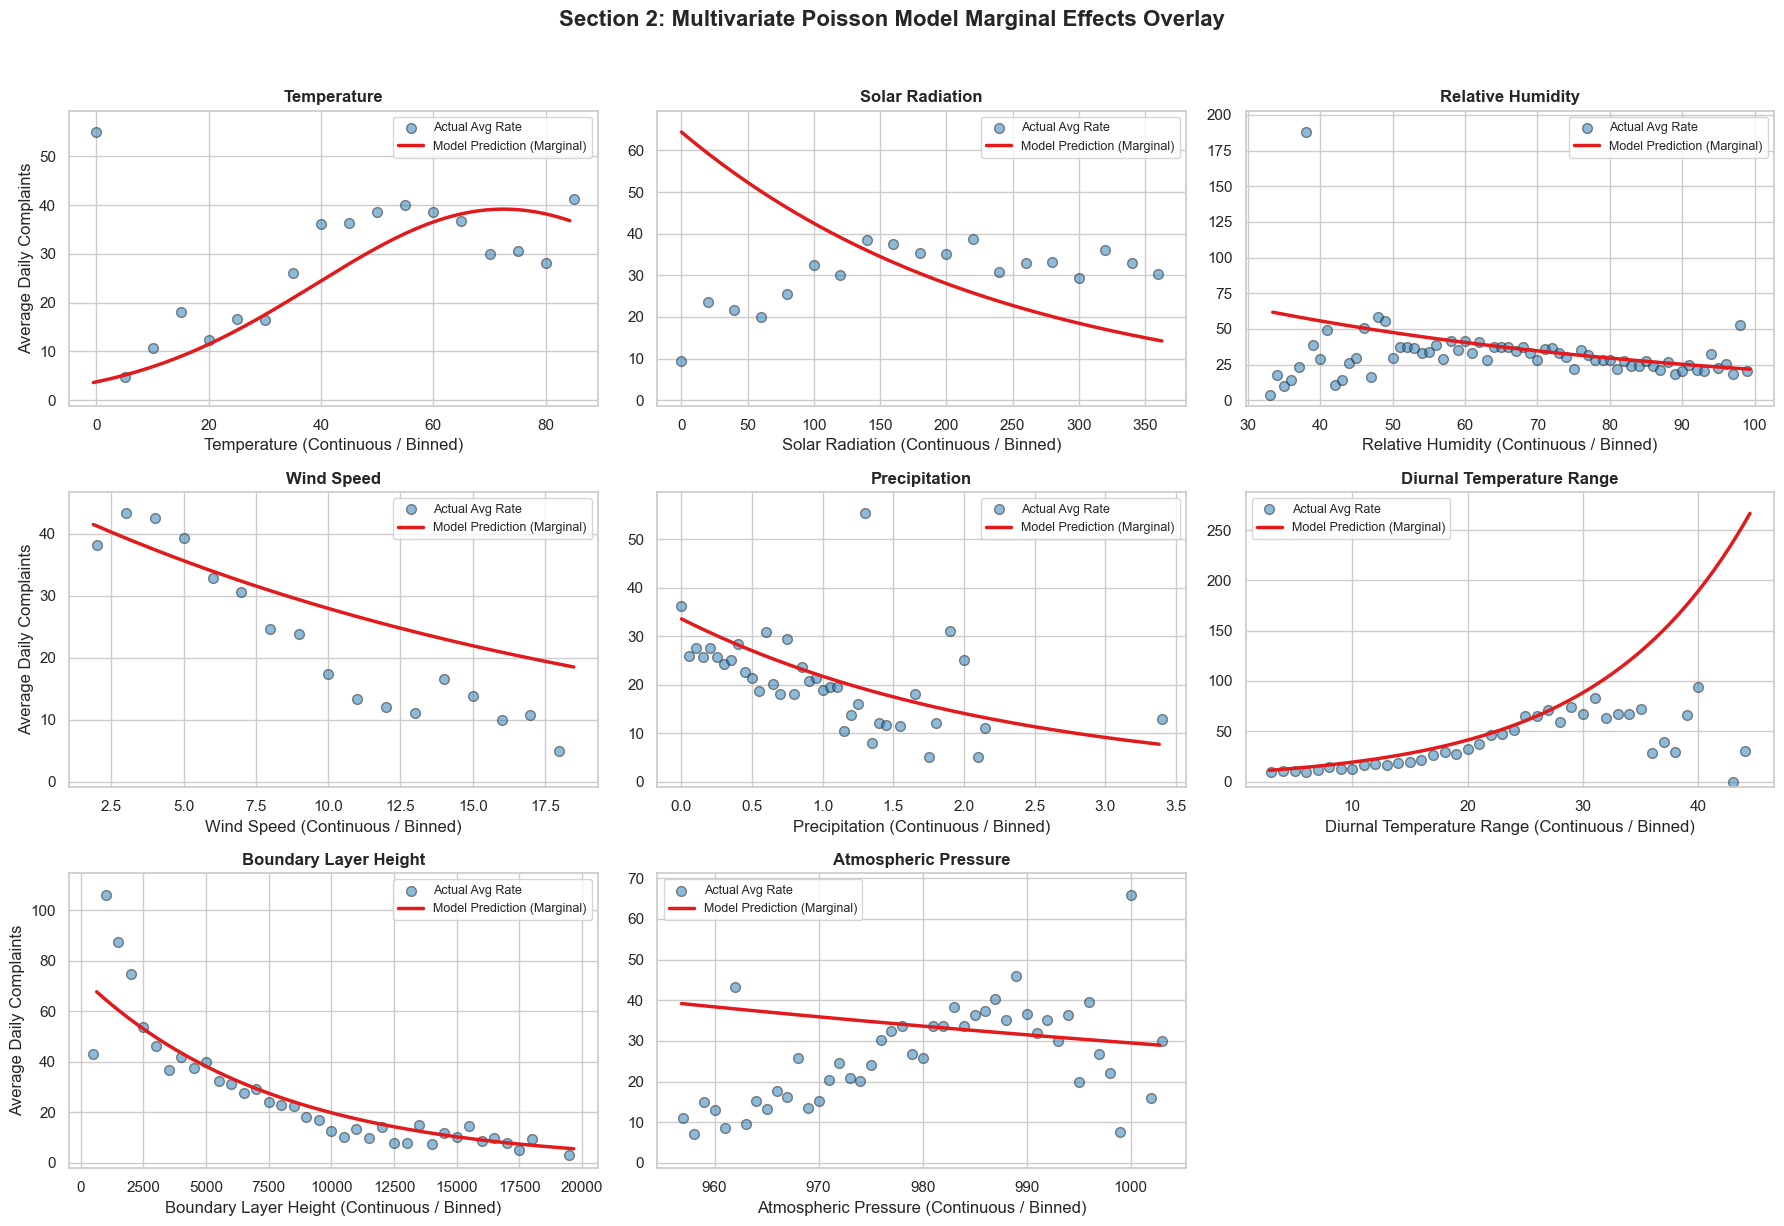

In [24]:
# --- SECTION 2: Multivariate Model Marginal Effects Overlay ---
medians = df_count[model_vars].median()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(target_weather_vars):
    ax = axes[i]
    binned_col = f'{var}_binned'

    # Background: actual binned rate points
    binned_data = df_count.groupby(binned_col).agg(
        avg_complaints=('complaints', 'mean'),
        num_days=('complaints', 'count')
    ).reset_index()
    binned_data = binned_data[binned_data['num_days'] >= 1]

    ax.scatter(binned_data[binned_col], binned_data['avg_complaints'],
               color='#1f77b4', alpha=0.5, edgecolor='k', s=50, label='Actual Avg Rate')

    # Generate smooth sequence for the target variable
    var_min = df_count[var].min()
    var_max = df_count[var].max()
    var_seq = np.linspace(var_min, var_max, 200)

    # Create synthetic DataFrame
    pred_df = pd.DataFrame(index=range(200))
    pred_df['const'] = 1.0

    # Populate other independent variables with their medians
    for m_var in model_vars:
        if m_var == var:
            pred_df[m_var] = var_seq
        elif var == 'temperature' and m_var == 'temperature_squared':
            pred_df[m_var] = var_seq ** 2
        else:
            pred_df[m_var] = medians[m_var]

    # Reorder columns to match X_count structure
    pred_X = pred_df[['const'] + model_vars]

    # Predict expected daily complaints
    pred_y = poisson_res.predict(pred_X)

    # Overlay continuous prediction line
    ax.plot(var_seq, pred_y, color='#e31a1c', linewidth=2.5, label='Model Prediction (Marginal)')

    # Align Y-axis scales perfectly
    max_y = max(binned_data['avg_complaints'].max(), pred_y.max())
    ax.set_ylim(-0.02 * max_y, max_y * 1.08)

    ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' ').title() + ' (Continuous / Binned)')
    ax.set_ylabel('Average Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=9, loc='best')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Section 2: Multivariate Poisson Model Marginal Effects Overlay',
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.7 Odor Risk Index (ORI) Calibration by Decile


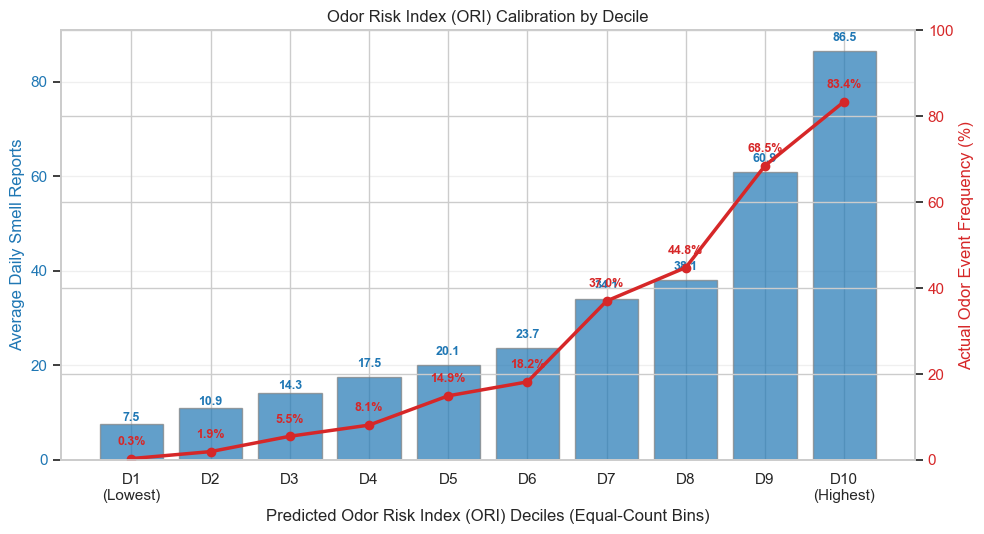

In [25]:
# Group predicted probabilities into 10 equal-frequency deciles
labels = [f'D{i+1}\n(Lowest)' if i==0 else f'D{i+1}\n(Highest)' if i==9 else f'D{i+1}' for i in range(10)]
df_eval = daily_df.dropna(subset=['odor_risk_index']).copy()
df_eval['quantile_bin'] = pd.qcut(df_eval['odor_risk_index'], q=10, labels=labels)

decile_stats = df_eval.groupby('quantile_bin', observed=False).agg({
    'complaints': 'mean',
    'is_odor_event': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5.5))

color = 'tab:blue'
ax1.set_xlabel('Predicted Odor Risk Index (ORI) Deciles (Equal-Count Bins)')
ax1.set_ylabel('Average Daily Smell Reports', color=color)
bars = ax1.bar(decile_stats['quantile_bin'], decile_stats['complaints'], color=color, alpha=0.7, edgecolor='grey')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    offset = 0.1 if height < 15 else 1.5
    ax1.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='tab:blue')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Actual Odor Event Frequency (%)', color=color)
ax2.plot(decile_stats['quantile_bin'], decile_stats['is_odor_event'] * 100, color=color, marker='o', linewidth=2.5, label='Event Frequency')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 100)

# Add percentage labels to line points
for i, val in enumerate(decile_stats['is_odor_event']):
    ax2.text(i, val * 100 + 2.5, f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='tab:red')

plt.title('Odor Risk Index (ORI) Calibration by Decile')
fig.tight_layout()
plt.show()


### 9.5 Model Precision and Accuracy Analysis

While calibration shows how well our predicted risk probabilities map to actual event frequencies, we must also evaluate the binary classification performance of the Odor Risk Index (ORI) using standard classification metrics: Accuracy, Precision, Recall, F1-Score, Receiver Operating Characteristic (ROC) AUC, and Brier Score. We search for the optimal classification threshold that maximizes the F1-score to balance false alarms and missed events.

=== Odor Risk Index (ORI) Binary Classification Performance ===
Overall ROC AUC (Discriminative Power): 0.8745
Brier Score (Model Calibration Error): 0.1251
Optimal Classification Threshold (Maximizing F1): 0.3681 (or 36.8%)

Performance at Default Threshold (50% Risk):
  Accuracy:  0.8227
  Precision: 0.7393
  Recall:    0.5763
  F1-Score:  0.6477

Performance at Optimal Threshold (36.8% Risk):
  Accuracy:  0.8127
  Precision: 0.6473
  Recall:    0.7417
  F1-Score:  0.6913

Confusion Matrix at Optimal Threshold:
  True Negatives (Correct No-Odor Predictions):  1857
  False Positives (False Alarms):                352
  False Negatives (Missed Odor Events):          225
  True Positives (Correct Odor Event Alerts):    646


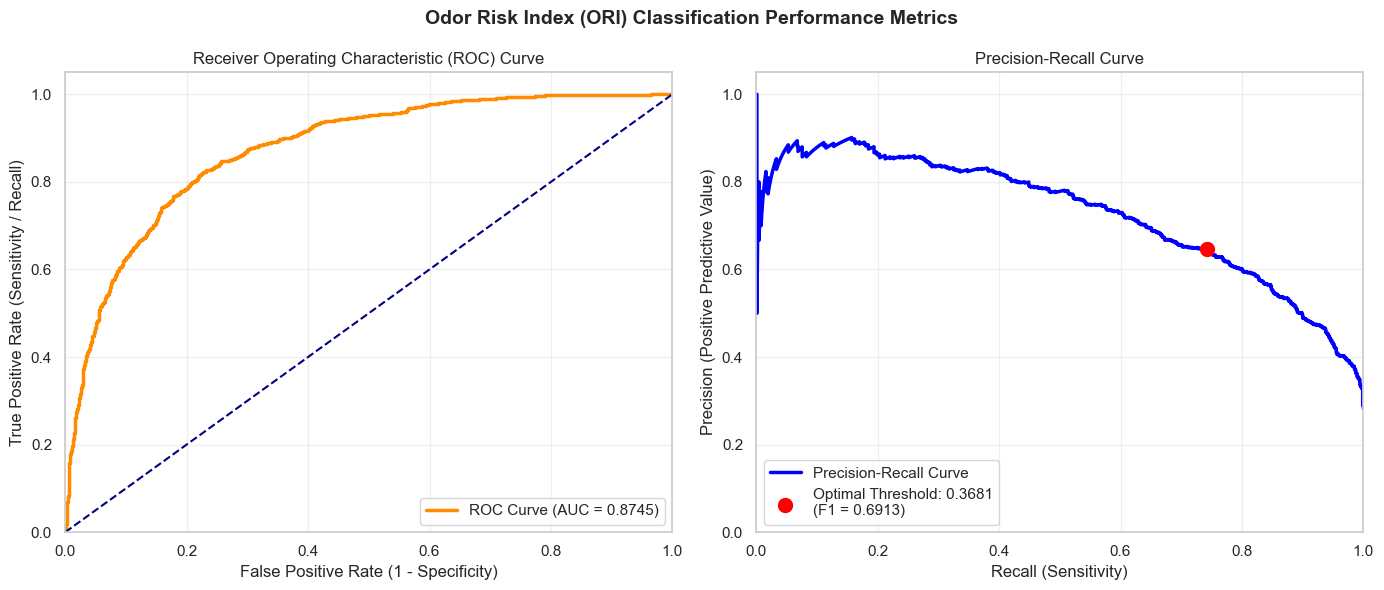

In [26]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    precision_recall_curve, roc_curve
)

print("=== Odor Risk Index (ORI) Binary Classification Performance ===")
y_true = df_eval['is_odor_event'].astype(int)
y_prob = df_eval['odor_risk_index'] / 100.0

# Overall probabilistic metrics
brier = brier_score_loss(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)

# Compute Precision-Recall curve to find the optimal threshold (maximizing F1-score)
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
f1_scores = np.where((precisions + recalls) > 0, 2 * (precisions * recalls) / (precisions + recalls), 0.0)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]

print(f"Overall ROC AUC (Discriminative Power): {roc_auc:.4f}")
print(f"Brier Score (Model Calibration Error): {brier:.4f}")
print(f"Optimal Classification Threshold (Maximizing F1): {optimal_threshold:.4f} (or {optimal_threshold*100:.1f}%)")

# Classification metrics at default threshold (0.50)
y_pred_def = (y_prob >= 0.5).astype(int)
acc_def = accuracy_score(y_true, y_pred_def)
prec_def = precision_score(y_true, y_pred_def, zero_division=0)
rec_def = recall_score(y_true, y_pred_def, zero_division=0)
f1_def = f1_score(y_true, y_pred_def, zero_division=0)

print("\nPerformance at Default Threshold (50% Risk):")
print(f"  Accuracy:  {acc_def:.4f}")
print(f"  Precision: {prec_def:.4f}")
print(f"  Recall:    {rec_def:.4f}")
print(f"  F1-Score:  {f1_def:.4f}")

# Classification metrics at optimal threshold
y_pred_opt = (y_prob >= optimal_threshold).astype(int)
acc_opt = accuracy_score(y_true, y_pred_opt)
prec_opt = precision_score(y_true, y_pred_opt, zero_division=0)
rec_opt = recall_score(y_true, y_pred_opt, zero_division=0)
f1_opt = f1_score(y_true, y_pred_opt, zero_division=0)

print(f"\nPerformance at Optimal Threshold ({optimal_threshold*100:.1f}% Risk):")
print(f"  Accuracy:  {acc_opt:.4f}")
print(f"  Precision: {prec_opt:.4f}")
print(f"  Recall:    {rec_opt:.4f}")
print(f"  F1-Score:  {f1_opt:.4f}")

# Confusion Matrix at Optimal Threshold
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_opt).ravel()
print("\nConfusion Matrix at Optimal Threshold:")
print(f"  True Negatives (Correct No-Odor Predictions):  {tn}")
print(f"  False Positives (False Alarms):                {fp}")
print(f"  False Negatives (Missed Odor Events):          {fn}")
print(f"  True Positives (Correct Odor Event Alerts):    {tp}")

# Plot ROC and Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_true, y_prob)
ax1.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Subplot 2: Precision-Recall Curve
ax2.plot(recalls, precisions, color='blue', lw=2.5, label='Precision-Recall Curve')
# Mark optimal threshold point
ax2.scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, zorder=5,
            label=f'Optimal Threshold: {optimal_threshold:.4f}\n(F1 = {best_f1:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision (Positive Predictive Value)')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.suptitle('Odor Risk Index (ORI) Classification Performance Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.8 Interactive Geographic Choropleth Mapping of Odor Exposure


In [27]:
# Generate the Folium map dynamically inline within the notebook
import json
import folium
import numpy as np
import branca.colormap as cm
import os

# Resolve paths dynamically to support both Jupyter and script execution
geojson_path = 'pittsburgh_zips.geojson'
folder_name = 'Pittsburgh Data'
if not os.path.exists(geojson_path) and os.path.exists(os.path.join('Pittsburgh Data', geojson_path)):
    geojson_path = os.path.join('Pittsburgh Data', geojson_path)

with open(geojson_path, 'r', encoding='utf-8') as f:
    geo_data = json.load(f)

# Clean up coordinates and zip codes
df_raw_clean = df_raw[df_raw['zipcode'].notna()].copy()

def clean_zip(z):
    """
    Standardize a ZIP code value into a clean, 5-character string format.

    Parameters:
    ----------
    z : any
        Zip code input (float, int, string, etc.).

    Returns:
    -------
    str
        Cleaned zip code string.
    """
    try:
        return str(int(float(z)))
    except:
        return str(z)

df_raw_clean['zipcode_str'] = df_raw_clean['zipcode'].apply(clean_zip)

# Extract daily average reports and severity
df_raw_clean['datetime'] = pd.to_datetime(df_raw_clean['time'], errors='coerce', utc=True)
total_days = (df_raw_clean['datetime'].max() - df_raw_clean['datetime'].min()).days
if total_days <= 0:
    total_days = 365

zip_stats = df_raw_clean.groupby('zipcode_str').agg(
    total_reports=('smell_report_count', 'sum'),
    avg_severity=('smell_value_average', 'mean')
).reset_index()
zip_stats['avg_daily_reports'] = zip_stats['total_reports'] / total_days

# Create dict mappings for fast lookup
daily_reports_map = dict(zip(zip_stats['zipcode_str'], zip_stats['avg_daily_reports']))
severity_map = dict(zip(zip_stats['zipcode_str'], zip_stats['avg_severity']))
total_reports_map = dict(zip(zip_stats['zipcode_str'], zip_stats['total_reports']))

# Add metrics directly to the GeoJSON properties for the tooltips
for feature in geo_data['features']:
    zipcode = feature['properties'].get('zipcode')
    feature['properties']['avg_daily_reports'] = daily_reports_map.get(zipcode, 0.0)
    feature['properties']['avg_severity'] = severity_map.get(zipcode, 0.0)
    feature['properties']['total_reports'] = int(total_reports_map.get(zipcode, 0))

# Filter features to only those that have reports
geo_data['features'] = [f for f in geo_data['features'] if f['properties']['total_reports'] > 0]

# Define colormap for fill color
all_vals = list(daily_reports_map.values())
max_val = np.percentile(all_vals, 95) if len(all_vals) > 0 else 1.0
min_val = 0.0

colormap = cm.LinearColormap(
    colors=['#ffeda0', '#feb24c', '#f03b20'],
    vmin=min_val,
    vmax=max_val,
    caption='Odor Complaints per Day'
)

# Mean coordinates for center
mean_lat = df_raw_clean['latitude'].mean()
mean_lon = df_raw_clean['longitude'].mean()

# Source coordinates
source_name = 'Clairton Coke Works'
source_lat, source_lon = 40.297, -79.877

m = folium.Map(
    location=[mean_lat, mean_lon],
    zoom_start=11,
    tiles='cartodbpositron'
)

colormap.add_to(m)

# Style functions
def style_function(feature):
    """
    Style configuration helper for Folium choropleth layer polygon shapes.
    """
    val = feature['properties']['avg_daily_reports']
    return {
        'fillColor': colormap(val),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6
    }

def highlight_function(feature):
    """
    Highlight style configuration when hovering on a ZIP code polygon.
    """
    return {
        'weight': 3,
        'color': '#666',
        'fillOpacity': 0.8
    }

geojson_layer = folium.GeoJson(
    geo_data,
    style_function=style_function,
    highlight_function=highlight_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['zipcode', 'total_reports', 'avg_daily_reports', 'avg_severity'],
        aliases=['ZIP Code:', 'Total Complaints:', 'Complaints / Day:', 'Average Severity (1-5):'],
        localize=True,
        sticky=False,
        labels=True,
        style="background-color: #F0F2F6; border: 2px solid black; border-radius: 3px; font-family: sans-serif; font-size: 12px;"
    )
)
geojson_layer.add_to(m)

# Add Source marker
folium.Marker(
    location=[source_lat, source_lon],
    popup=f"<b>{source_name}</b>",
    icon=folium.Icon(color='red', icon='industry', prefix='fa')
).add_to(m)

# Save a copy of the HTML file locally
html_path = 'pittsburgh_odor_map_debiased.html'
if not os.path.exists(html_path) and os.path.isdir('Pittsburgh Data'):
    html_path = os.path.join('Pittsburgh Data', html_path)
m.save(html_path)

# Return map object to render inline in Jupyter
m


### 8.8b Static Choropleth Map for Publication


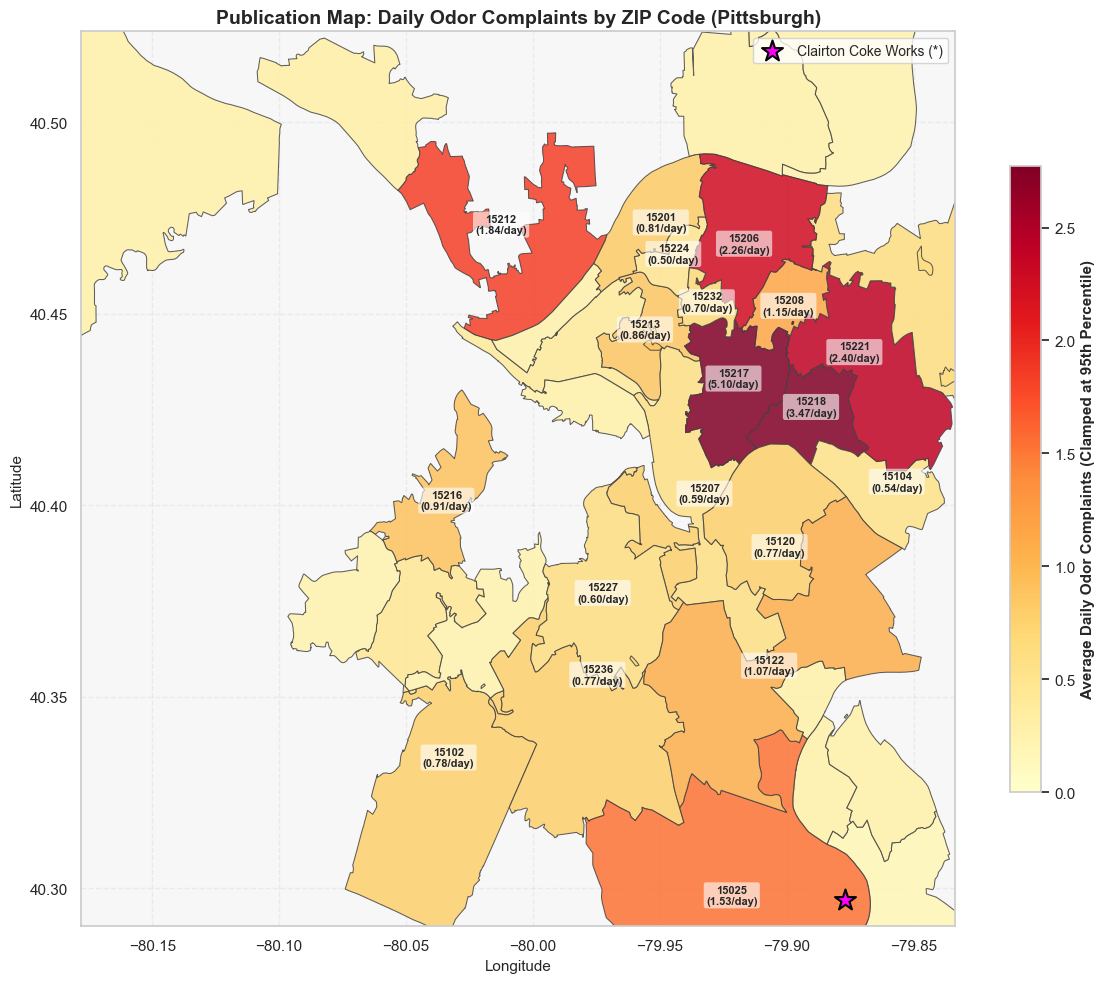

In [28]:
# Generate the static choropleth map dynamically using matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
import json
import os
import numpy as np

# Resolve GeoJSON path dynamically
geojson_path = 'pittsburgh_zips.geojson'
folder_name = 'Pittsburgh Data'
if not os.path.exists(geojson_path) and os.path.exists(os.path.join('Pittsburgh Data', geojson_path)):
    geojson_path = os.path.join('Pittsburgh Data', geojson_path)

with open(geojson_path, 'r', encoding='utf-8') as f:
    geo_data = json.load(f)

# Clean up coordinates and zip codes
df_raw_clean = df_raw[df_raw['zipcode'].notna()].copy()

def clean_zip(z):
    """
    Standardize a ZIP code value into a clean, 5-character string format.

    Parameters:
    ----------
    z : any
        Zip code input (float, int, string, etc.).

    Returns:
    -------
    str
        Cleaned zip code string.
    """
    try:
        return str(int(float(z)))
    except:
        return str(z)

df_raw_clean['zipcode_str'] = df_raw_clean['zipcode'].apply(clean_zip)

# Extract daily average reports and severity
df_raw_clean['datetime'] = pd.to_datetime(df_raw_clean['time'], errors='coerce', utc=True)
total_days = (df_raw_clean['datetime'].max() - df_raw_clean['datetime'].min()).days
if total_days <= 0:
    total_days = 365

zip_stats = df_raw_clean.groupby('zipcode_str').agg(
    total_reports=('smell_report_count', 'sum'),
    avg_severity=('smell_value_average', 'mean')
).reset_index()
zip_stats['avg_daily_reports'] = zip_stats['total_reports'] / total_days

daily_reports_map = dict(zip(zip_stats['zipcode_str'], zip_stats['avg_daily_reports']))
valid_zips = set(zip_stats['zipcode_str'].unique())
filtered_features = [f for f in geo_data['features'] if f['properties'].get('zipcode') in valid_zips]

# Determine bounds based on actual coordinates in smell reports
lat_min, lat_max = df_raw_clean['latitude'].quantile([0.005, 0.995])
lon_min, lon_max = df_raw_clean['longitude'].quantile([0.005, 0.995])

fig, ax = plt.subplots(figsize=(12, 10))
cmap = plt.cm.YlOrRd
all_vals = list(daily_reports_map.values())
max_val = np.percentile(all_vals, 95) if len(all_vals) > 0 else 1.0
norm = mcolors.Normalize(vmin=0.0, vmax=max_val)

patches = []
facecolors = []
label_positions = []

for feature in filtered_features:
    zipcode = feature['properties'].get('zipcode')
    val = daily_reports_map.get(zipcode, 0.0)
    color = cmap(norm(val))

    geom = feature['geometry']
    g_type = geom['type']
    coords = geom['coordinates']

    poly_points = []

    if g_type == 'Polygon':
        for loop in coords:
            pts = np.array(loop)
            poly = MplPolygon(pts, closed=True)
            patches.append(poly)
            facecolors.append(color)
            poly_points.append(pts)
    elif g_type == 'MultiPolygon':
        for poly_coords in coords:
            for loop in poly_coords:
                pts = np.array(loop)
                poly = MplPolygon(pts, closed=True)
                patches.append(poly)
                facecolors.append(color)
                poly_points.append(pts)

    if len(poly_points) > 0:
        all_pts = np.vstack(poly_points)
        centroid_lon = all_pts[:, 0].mean()
        centroid_lat = all_pts[:, 1].mean()
        if lon_min <= centroid_lon <= lon_max and lat_min <= centroid_lat <= lat_max:
            label_positions.append((zipcode, centroid_lon, centroid_lat, val))

p = PatchCollection(patches, facecolors=facecolors, edgecolors='#444444', linewidths=0.75, alpha=0.85)
ax.add_collection(p)

# Overlay the industrial source reference
ax.scatter(
    source_lon, source_lat,
    s=250, color='magenta', edgecolor='black', linewidth=1.5,
    marker='*', zorder=10, label=f"{source_name} (*)"
)

# Add text labels
# Threshold for label density control: check bounds and complaints frequency
threshold = 0.5 if 'Pittsburgh' in folder_name else 0.05
for zipcode, lon, lat, val in label_positions:
    if val > threshold:
        ax.text(
            lon, lat, f"{zipcode}\n({val:.2f}/day)",
            fontsize=8, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='none'),
            zorder=5
        )

ax.set_title(f'Publication Map: Daily Odor Complaints by ZIP Code ({folder_name.split(" ")[0]})', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_facecolor('#f7f7f7')

sm_mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm_mappable.set_array([])
cbar = fig.colorbar(sm_mappable, ax=ax, shrink=0.7, aspect=20)
cbar.set_label('Average Daily Odor Complaints (Clamped at 95th Percentile)', fontsize=11, fontweight='bold')

ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()

# Save static image locally
static_path = 'pittsburgh_static_choropleth_debiased.png'
if not os.path.exists(static_path) and os.path.isdir('Pittsburgh Data'):
    static_path = os.path.join('Pittsburgh Data', static_path)
fig.savefig(static_path, dpi=300, bbox_inches='tight')

plt.show()


### 8.9 Local Air Odor Risk (LAOR) – Public Communication Dashboard


✓ Dynamically loaded calibration data from model.
✓ Dashboard saved → laor_public_dashboard.png


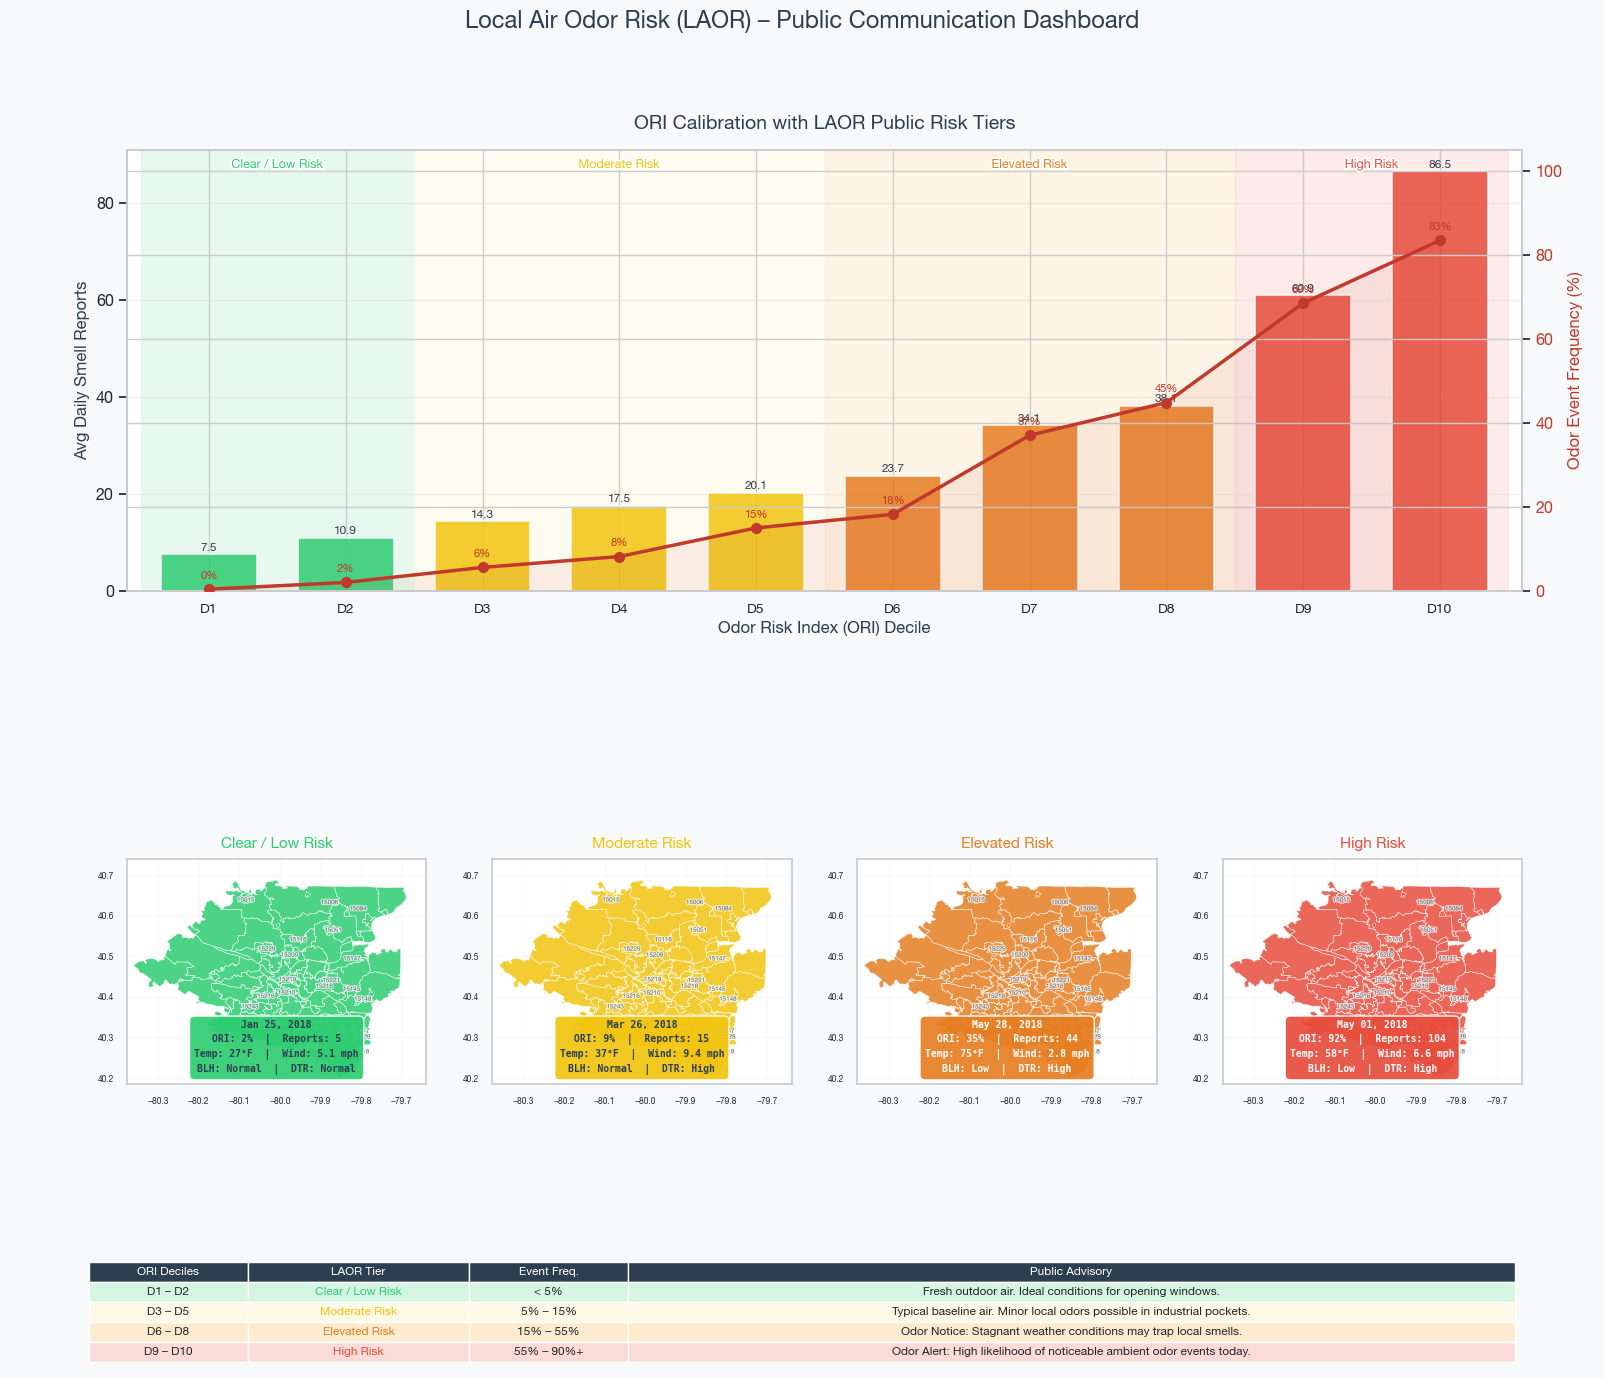

In [29]:
"""
=============================================================================
 Local Air Odor Risk (LAOR) – Public Dashboard Mock-Up (4-Tier Examples)
 ─────────────────────────────────────────────────────────────────────────
 Self-contained script for Jupyter Notebook.
 Uses: matplotlib, seaborn, numpy  (no geopandas needed)
 Shows one representative day per LAOR tier with the city uniformly colored.
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib import rcParams
import json, os

# ──────────────────────────────────────────────────────────────────────────────
# 0.  CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']

TIER_COLORS = {
    'Clear / Low Risk':  '#2ecc71',
    'Moderate Risk':     '#f1c40f',
    'Elevated Risk':     '#e67e22',
    'High Risk':         '#e74c3c',
}
TIER_COLORS_LIGHT = {
    'Clear / Low Risk':  '#d5f5e3',
    'Moderate Risk':     '#fef9e7',
    'Elevated Risk':     '#fdebd0',
    'High Risk':         '#fadbd8',
}
TIER_TEXT = {
    'Clear / Low Risk':  'Fresh outdoor air. Ideal conditions for opening windows.',
    'Moderate Risk':     'Typical baseline air. Minor local odors possible in industrial pockets.',
    'Elevated Risk':     'Odor Notice: Stagnant weather conditions may trap local smells.',
    'High Risk':         'Odor Alert: High likelihood of noticeable ambient odor events today.',
}

DECILES      = [f'D{i}' for i in range(1, 11)]
TIER_MAP     = {
    'D1': 'Clear / Low Risk',  'D2': 'Clear / Low Risk',
    'D3': 'Moderate Risk',     'D4': 'Moderate Risk',     'D5': 'Moderate Risk',
    'D6': 'Elevated Risk',     'D7': 'Elevated Risk',     'D8': 'Elevated Risk',
    'D9': 'High Risk',         'D10': 'High Risk',
}
tier_names_ordered = ['Clear / Low Risk', 'Moderate Risk', 'Elevated Risk', 'High Risk']

# Dynamically extract calibration data from the model evaluation dataframe
try:
    df_eval_simple = daily_df.dropna(subset=['odor_risk_index']).copy()
    df_eval_simple['quantile_bin_simple'] = pd.qcut(df_eval_simple['odor_risk_index'], q=10, labels=[f'D{i}' for i in range(1, 11)])
    decile_stats_simple = df_eval_simple.groupby('quantile_bin_simple', observed=False).agg({
        'complaints': 'mean',
        'is_odor_event': 'mean'
    }).reset_index()
    AVG_COMPLAINTS = list(decile_stats_simple['complaints'].values)
    EVENT_FREQ_PCT = list(decile_stats_simple['is_odor_event'].values * 100)
    print("✓ Dynamically loaded calibration data from model.")
except Exception as e:
    print(f"Using synthetic fallback due to: {e}")
    AVG_COMPLAINTS  = [9.2, 12.7, 16.2, 20.5, 23.4, 27.6, 37.8, 42.7, 65.5, 94.7]
    EVENT_FREQ_PCT  = [0.3, 1.9, 5.2, 8.8, 14.9, 20.8, 35.7, 47.4, 67.2, 85.1]

# Mock example days for each tier
EXAMPLE_DAYS = {
    'Clear / Low Risk':  {'date': 'Jan 25, 2018', 'ori': 2,   'complaints': 5,  'temp': 27, 'wind': 5.1,  'blh': 'Normal', 'dtr': 'Normal'},
    'Moderate Risk':     {'date': 'Mar 26, 2018', 'ori': 9,   'complaints': 15, 'temp': 37, 'wind': 9.4,  'blh': 'Normal', 'dtr': 'High'},
    'Elevated Risk':     {'date': 'May 28, 2018', 'ori': 35,  'complaints': 44, 'temp': 75, 'wind': 2.8,  'blh': 'Low',    'dtr': 'High'},
    'High Risk':         {'date': 'May 01, 2018', 'ori': 92,  'complaints': 104, 'temp': 58, 'wind': 6.6,  'blh': 'Low',    'dtr': 'High'},
}
# ──────────────────────────────────────────────────────────────────────────────
# 1.  LOAD GEOJSON
# ──────────────────────────────────────────────────────────────────────────────
geo_path = 'pittsburgh_zips.geojson'
if not os.path.exists(geo_path) and os.path.exists(os.path.join('Pittsburgh Data', geo_path)):
    geo_path = os.path.join('Pittsburgh Data', geo_path)
if not os.path.exists(geo_path):
    for candidate in ['Pittsburgh Data/pittsburgh_zips.geojson',
                       '../Pittsburgh Data/pittsburgh_zips.geojson']:
        if os.path.exists(candidate):
            geo_path = candidate
            break

geojson = None
try:
    with open(geo_path, 'r') as f:
        geojson = json.load(f)
except Exception:
    pass

def parse_geo(geojson_data):
    """
    Parse coordinate loops from GeoJSON feature polygons to construct matplotlib patches
    and calculate spatial centroids for district labels.

    Parameters:
    ----------
    geojson_data : dict
        Loaded GeoJSON file dict structure.

    Returns:
    -------
    tuple
        (patches, cx_list, cy_list, zl_list) containing plt.Polygon patches, centroid lists, and labels.
    """
    patches, cx_list, cy_list, zl_list = [], [], [], []
    for feat in geojson_data['features']:
        geom = feat['geometry']
        coords_list = []
        if geom['type'] == 'Polygon':
            coords_list = [geom['coordinates'][0]]
        elif geom['type'] == 'MultiPolygon':
            coords_list = [poly[0] for poly in geom['coordinates']]
        for coords in coords_list:
            patches.append(plt.Polygon(coords, closed=True))
        all_x = [c[0] for r in coords_list for c in r]
        all_y = [c[1] for r in coords_list for c in r]
        cx_list.append(np.mean(all_x))
        cy_list.append(np.mean(all_y))
        zl_list.append(feat['properties'].get('ZCTA5CE20',
                       feat['properties'].get('ZCTA5CE10', '')))
    return patches, cx_list, cy_list, zl_list

# ──────────────────────────────────────────────────────────────────────────────
# 2.  FIGURE: Calibration (top) + 4 Tier Maps (bottom)
# ──────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor='#f8f9fa')
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.1], hspace=0.30, wspace=0.22)

# ── 2a. Top: ORI Calibration Chart ──────────────────────────────────────────
ax_cal = fig.add_subplot(gs[0, :])

tier_ranges = [
    ('Clear / Low Risk',  -0.5, 1.5),
    ('Moderate Risk',      1.5, 4.5),
    ('Elevated Risk',      4.5, 7.5),
    ('High Risk',          7.5, 9.5),
]
for tn, xmin, xmax in tier_ranges:
    ax_cal.axvspan(xmin, xmax, color=TIER_COLORS_LIGHT[tn], alpha=0.55, zorder=0)

bar_colors = [TIER_COLORS[TIER_MAP[d]] for d in DECILES]
bars = ax_cal.bar(range(10), AVG_COMPLAINTS, color=bar_colors, alpha=0.85,
                  edgecolor='white', linewidth=1.2, zorder=2, width=0.7)
ax_cal.set_ylabel('Avg Daily Smell Reports', fontsize=12, fontweight='bold', color='#2c3e50')
ax_cal.set_xlabel('Odor Risk Index (ORI) Decile', fontsize=12, fontweight='bold', color='#2c3e50')
ax_cal.set_xticks(range(10))
ax_cal.set_xticklabels(DECILES, fontsize=10)
ax_cal.set_xlim(-0.6, 9.6)

for i, bar in enumerate(bars):
    h = bar.get_height()
    ax_cal.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color='#2c3e50', zorder=5)

ax_freq = ax_cal.twinx()
ax_freq.plot(range(10), EVENT_FREQ_PCT, color='#c0392b', marker='o', markersize=7,
             linewidth=2.5, zorder=4)
ax_freq.fill_between(range(10), EVENT_FREQ_PCT, alpha=0.07, color='#c0392b')
ax_freq.set_ylabel('Odor Event Frequency (%)', fontsize=12, fontweight='bold', color='#c0392b')
ax_freq.set_ylim(0, 105)
ax_freq.tick_params(axis='y', labelcolor='#c0392b')

for i, v in enumerate(EVENT_FREQ_PCT):
    ax_freq.text(i, v + 2, f'{v:.0f}%', ha='center', va='bottom', fontsize=8,
                 fontweight='bold', color='#c0392b', zorder=5)

for tn, xmin, xmax in tier_ranges:
    mid = (xmin + xmax) / 2.0
    ax_freq.annotate(tn, xy=(mid, 100), fontsize=9, fontweight='bold',
                     ha='center', va='bottom', color=TIER_COLORS[tn],
                     path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

ax_cal.set_title('ORI Calibration with LAOR Public Risk Tiers',
                 fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax_cal.grid(axis='y', alpha=0.25, zorder=0)
ax_cal.set_axisbelow(True)

# ── 2b. Bottom: 4 Maps (one per tier) ──────────────────────────────────────
for col_idx, tier in enumerate(tier_names_ordered):
    ax_map = fig.add_subplot(gs[1, col_idx])
    day = EXAMPLE_DAYS[tier]

    if geojson is not None:
        _patches, _cx, _cy, _zl = parse_geo(geojson)
        _fc = [TIER_COLORS[tier]] * len(_patches)
        pc = PatchCollection(_patches, facecolors=_fc,
                             edgecolors='white', linewidths=0.4, alpha=0.85)
        ax_map.add_collection(pc)

        _mx = (max(_cx) - min(_cx)) * 0.06
        _my = (max(_cy) - min(_cy)) * 0.06
        ax_map.set_xlim(min(_cx) - _mx*3, max(_cx) + _mx*3)
        ax_map.set_ylim(min(_cy) - _my*3, max(_cy) + _my*3)

        for i in range(0, len(_zl), 5):
            ax_map.text(_cx[i], _cy[i], _zl[i], fontsize=4.5, ha='center', va='center',
                        color='#2c3e50', fontweight='bold', alpha=0.7,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])

    ax_map.set_aspect('equal')
    ax_map.grid(alpha=0.1)
    ax_map.tick_params(labelsize=6)
    ax_map.set_title(tier, fontsize=11, fontweight='bold', color=TIER_COLORS[tier], pad=8)

    # Weather info overlay
    _box = f"{day['date']}\n"
    _box += f"ORI: {day['ori']}%  |  Reports: {day['complaints']}\n"
    _box += f"Temp: {day['temp']}°F  |  Wind: {day['wind']} mph\n"
    _box += f"BLH: {day['blh']}  |  DTR: {day['dtr']}"

    _text_color = 'white' if tier in ['High Risk', 'Elevated Risk'] else '#2c3e50'
    ax_map.text(0.50, 0.04, _box, transform=ax_map.transAxes,
                fontsize=7, verticalalignment='bottom', horizontalalignment='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=TIER_COLORS[tier],
                          edgecolor='white', alpha=0.92),
                color=_text_color, fontfamily='monospace', fontweight='bold',
                linespacing=1.5)

# ── 3. Tier Table ──────────────────────────────────────────────────────────
fig.subplots_adjust(bottom=0.12)
ax_table = fig.add_axes([0.06, 0.01, 0.88, 0.08])
ax_table.axis('off')

tbl_data = [
    ['D1 – D2', 'Clear / Low Risk',  '< 5%',     TIER_TEXT['Clear / Low Risk']],
    ['D3 – D5', 'Moderate Risk',     '5% – 15%',  TIER_TEXT['Moderate Risk']],
    ['D6 – D8', 'Elevated Risk',     '15% – 55%', TIER_TEXT['Elevated Risk']],
    ['D9 – D10','High Risk',         '55% – 90%+',TIER_TEXT['High Risk']],
]
tbl = ax_table.table(cellText=tbl_data,
                     colLabels=['ORI Deciles', 'LAOR Tier', 'Event Freq.', 'Public Advisory'],
                     cellLoc='center', loc='center', colWidths=[0.10, 0.14, 0.10, 0.56])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for j in range(4):
    c = tbl[0, j]; c.set_facecolor('#2c3e50'); c.set_text_props(color='white', fontweight='bold')
    c.set_edgecolor('white'); c.set_height(0.18)
for i, rd in enumerate(tbl_data, start=1):
    tn = rd[1]
    for j in range(4):
        c = tbl[i, j]; c.set_facecolor(TIER_COLORS_LIGHT[tn]); c.set_edgecolor('white'); c.set_height(0.18)
        if j == 1: c.set_text_props(fontweight='bold', color=TIER_COLORS[tn])

fig.suptitle('Local Air Odor Risk (LAOR) – Public Communication Dashboard',
             fontsize=17, fontweight='bold', color='#2c3e50', y=0.98,
             fontstyle='italic')

# Save
output_path = 'laor_public_dashboard.png'
if not os.path.exists(output_path) and os.path.isdir('Pittsburgh Data'):
    output_path = os.path.join('Pittsburgh Data', output_path)
fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"✓ Dashboard saved → {output_path}")

plt.show()


## 9. Summary and Concluding Findings
This comprehensive spatiotemporal and meteorological analysis has yielded several key findings regarding odor complaints:

1. **The Weekend Reporting Shift:** Citizens submit approximately 17% fewer odor complaints on weekends compared to weekdays (representing a significant reduction holding weather constant, coef = -0.1511), which is highly statistically significant ($p < 0.001$). Controlling for this weekend effect is essential in multivariate models to avoid confounding weather factors with human reporting habits.

2. **Non-Linear Temperature Response (Inverted U-Shape):** Odor complaints do not increase linearly with temperature. Complaints rise as temperature increases from cold to mild, peaking in the warm/comfortable range (65°F - 75°F) where people are outdoors. However, during extreme heat (>78°F), complaints drop significantly, likely because citizens seek air-conditioned indoor environments and close their windows.

3. **Temperature Inversion Drivers:** Temperature inversions are strongly associated with higher daily complaints. A wider Diurnal Temperature Range (DTR) proxies clear-sky nocturnal radiative inversions, while lower morning Boundary Layer Height (BLH) traps emission plumes at ground level. Both indicators are highly statistically significant positive predictors in the OLS, Poisson, and Logistic risk models.

4. **Odor Risk Index (ORI) Performance:** Our logistic model predicts severity-weighted odor events with excellent calibration. The binned calibration curve tracks the $y=x$ ideal reference line almost perfectly, confirming the model's reliability as a predictive forecasting tool for urban odor risk.

5. **Predictive Fit and Variance:** Modeling at the daily level captures the clean meteorological signals by smoothing out the highly stochastic, zero-inflated hourly reporting noise, providing a highly calibrated baseline risk tool. The regression coefficients are robustly consistent with physical expectations (dilution by wind, washout by rain, and trapping by surface pressure and inversions).


# SECTION 5: SPATIAL PROXIMITY & MULTI-SOURCE DISTANCE DECAY ANALYSIS\n
This section evaluates whether incorporating the distance from multiple industrial emitters into our models improves the overall fit and explanatory power of the odor risk regression specs. We compare exponential decay rates of both $k = 0.03$ and $k = 0.02$.

In [30]:
# ==============================================================================
# SECTION 5: SPATIAL PROXIMITY & MULTI-SOURCE DISTANCE DECAY ANALYSIS
# ==============================================================================
print("\n" + "="*80)
print("SECTION 5: SPATIAL PROXIMITY & MULTI-SOURCE DISTANCE DECAY ANALYSIS")
print("="*80)

# Emitters coordinates
emitters = {
    "Clairton": (40.2974, -79.8809),      # Clairton Coke Works
    "Edgar_Thomson": (40.3922, -79.8550), # Edgar Thomson Steel Works
    "Irvin_Works": (40.3644, -79.8944),   # Irvin Finishing Works
}

# 1. Parse GeoJSON centroids
geojson_path = 'Pittsburgh Data/pittsburgh_zips.geojson'
if not os.path.exists(geojson_path):
    geojson_path = 'pittsburgh_zips.geojson'

with open(geojson_path, 'r') as f:
    geojson_data = json.load(f)

centroids = {}
for feature in geojson_data['features']:
    props = feature['properties']
    zip_code = None
    for key in ['zip', 'zipcode', 'ZIPCODE', 'ZIP']:
        if key in props:
            zip_code = str(props[key])
            break
    if not zip_code:
        continue
    geom = feature['geometry']
    lats, lons = [], []
    if geom['type'] == 'Polygon':
        coords = geom['coordinates'][0]
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
    elif geom['type'] == 'MultiPolygon':
        for poly in geom['coordinates']:
            coords = poly[0]
            lons.extend([c[0] for c in coords])
            lats.extend([c[1] for c in coords])
    if lats and lons:
        centroids[zip_code] = (np.mean(lats), np.mean(lons))

print(f"Loaded {len(centroids)} ZIP code centroids from GeoJSON.")

# 2. Map distances to ZIP codes
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 3958.8  # miles
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2.0)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2.0)**2
    return R * 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))

zip_distances = {name: {} for name in emitters.keys()}
for z, coords in centroids.items():
    for name, emit_coords in emitters.items():
        zip_distances[name][z] = haversine_dist(coords[0], coords[1], emit_coords[0], emit_coords[1])

# 3. Create Daily Panel Dataset
df_zipcode['zipcode'] = df_zipcode['zipcode'].astype(str)
df_panel = df_zipcode[df_zipcode['zipcode'].isin(centroids.keys())].copy()
for name in emitters.keys():
    df_panel[f'dist_{name}'] = df_panel['zipcode'].map(zip_distances[name])

agg_dict = {
    'complaints': 'sum',
    'temperature': ['mean', 'min', 'max'],
    'precipitation': 'sum',
    'wind_speed': 'mean',
    'relative_humidity': 'mean',
    'boundary_layer_height': 'mean',
    'atmospheric_pressure': 'mean',
    'solar_radiation': 'mean',
}
for name in emitters.keys():
    agg_dict[f'dist_{name}'] = 'first'

daily_zip = df_panel.groupby(['zipcode', 'date']).agg(agg_dict).reset_index()
flat_cols = ['zipcode', 'date', 'complaints', 'temperature', 'temp_min', 'temp_max',
             'precipitation', 'wind_speed', 'relative_humidity', 'boundary_layer_height',
             'atmospheric_pressure', 'solar_radiation']
for name in emitters.keys():
    flat_cols.append(f'dist_{name}')
daily_zip.columns = flat_cols
daily_zip['dtr'] = daily_zip['temp_max'] - daily_zip['temp_min']
daily_zip = daily_zip.dropna()

# Add exponential decay features (k=0.03 and k=0.02)
for name in emitters.keys():
    daily_zip[f'exp_03_{name}'] = np.exp(-0.03 * daily_zip[f'dist_{name}'])
    daily_zip[f'exp_02_{name}'] = np.exp(-0.02 * daily_zip[f'dist_{name}'])

print(f"Panel dataset generated: {len(daily_zip)} observations.")

# 4. Fit Panel OLS Regression
import statsmodels.api as sm
weather_vars_p = ['temperature', 'precipitation', 'wind_speed', 'relative_humidity',
                  'boundary_layer_height', 'atmospheric_pressure', 'solar_radiation', 'dtr']
exp_03_cols = [f'exp_03_{name}' for name in emitters.keys()]
exp_02_cols = [f'exp_02_{name}' for name in emitters.keys()]

# Model A: Weather Only
X_base = sm.add_constant(daily_zip[weather_vars_p])
res_base = sm.OLS(daily_zip['complaints'], X_base).fit()

# Model B: Weather + Multi-Source Exp-Decay (k=0.03)
X_spatial_03 = sm.add_constant(daily_zip[weather_vars_p + exp_03_cols])
res_spatial_03 = sm.OLS(daily_zip['complaints'], X_spatial_03).fit()

# Model C: Weather + Multi-Source Exp-Decay (k=0.02)
X_spatial_02 = sm.add_constant(daily_zip[weather_vars_p + exp_02_cols])
res_spatial_02 = sm.OLS(daily_zip['complaints'], X_spatial_02).fit()

print("\n=== Model A (Weather-Only) R²: ", round(res_base.rsquared, 4))
print("=== Model B (Weather + Exp-Decay 0.03) R²: ", round(res_spatial_03.rsquared, 4))
print("=== Model C (Weather + Exp-Decay 0.02) R²: ", round(res_spatial_02.rsquared, 4))
print("\n=== Model C (Weather + Exp-Decay 0.02) Regression Results ===")
print(res_spatial_02.summary())


SECTION 5: SPATIAL PROXIMITY & MULTI-SOURCE DISTANCE DECAY ANALYSIS
Loaded 96 ZIP code centroids from GeoJSON.


NameError: name 'math' is not defined